# 배터리팩 레이저 용접 — 공정능력 기반 분석

**데이터** KAMP 전자부품(배터리팩) 예지보전 AI 데이터셋
**대상 설비** 전기버스용 배터리모듈 레이저 용접기
**분석 관점** 제조 표준 지표(Cp / Cpk / Pp / Ppk)로 설비 상태를 진단하고, 장기 열화를 예측한다

---

## 이 노트북이 답하려는 질문

1. 이 설비는 규격 안에서 어디쯤 돌고 있는가
2. 단기 능력과 장기 능력이 다른가
3. 다르다면 무엇이 그 차이를 만드는가
4. 지금 추세라면 언제 규격을 벗어나는가

## 왜 공정능력인가

가이드북은 이상탐지 성능(F1)만 본다. 그런데 현장에서 쓰는 언어는 다르다.
**"불량을 몇 개 맞혔나"가 아니라 "이 공정이 규격을 지킬 능력이 있나"**를 묻는다.
그 질문에 답하는 표준 지표가 Cp / Cpk / Pp / Ppk다.

## 0. 환경 설정

In [1]:
import os, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams['font.family'] = 'Malgun Gothic'   # 맥이면 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 60)

print('준비 완료')

준비 완료


## 1. 데이터 적재

원본을 그대로 읽는다. 컬럼명 앞뒤 공백만 제거한다 — 원본 헤더에 공백이 섞여 있어
그대로 쓰면 컬럼 접근 시 KeyError가 난다.

In [2]:
ROOT = r'c:\Users\wm032\Documents\KAMP\battery'      # ← 자기 경로로 수정
BASE = os.path.join(ROOT, 'Dataset_전자부품(배터리팩) 예지보전 AI 데이터셋', 'data')

def load_clean(p):
    return pd.read_csv(p).rename(columns=lambda c: c.strip())

RAW = {
    'train': load_clean(os.path.join(BASE,'raw_data','train','Training_Data.csv')),
    'ok1':   load_clean(os.path.join(BASE,'raw_data','test','WeldingTest_01_OK.csv')),
    'ok2':   load_clean(os.path.join(BASE,'raw_data','test','WeldingTest_02_OK.csv')),
    'ng3':   load_clean(os.path.join(BASE,'raw_data','test','WeldingTest_03_NG.csv')),
    'ng4':   load_clean(os.path.join(BASE,'raw_data','test','WeldingTest_04_NG.csv')),
}
LAB3 = pd.read_csv(os.path.join(BASE,'preprocessed','test','WeldingTest_03_NG_Label.csv'))['label']
LAB4 = pd.read_csv(os.path.join(BASE,'preprocessed','test','WeldingTest_04_NG_Label.csv'))['label']

for k, v in RAW.items():
    print(f'{k:6} {str(v.shape):>14}  결측 {v.isna().sum().sum()}  중복 {v.duplicated().sum()}')

train     (135759, 9)  결측 0  중복 0
ok1         (1950, 9)  결측 0  중복 0
ok2         (1872, 9)  결측 0  중복 0
ng3         (1053, 9)  결측 0  중복 0
ng4          (351, 9)  결측 0  중복 0


**확인 결과**

| 파일 | 행 | 결측 | 중복 |
|---|---|---|---|
| train | 135,759 | 0 | 0 |
| ok1 / ok2 | 1,950 / 1,872 | 0 | 0 |
| ng3 / ng4 | 1,053 / 351 | 0 | 0 |

> ⚠️ **가이드북 불일치 ①** — 가이드북은 데이터 개수를 1,268,865개로 적었다.
> 그런데 135,759 × 9 = 1,221,831이다. **행 수가 아니라 셀 개수를 적은 것**이다.

## 2. 변수별 상태 — 무엇을 버리고 무엇을 쓸 것인가

숫자 표만 보면 놓치는 게 있어서 **고유값 개수를 막대로** 그린다.
막대가 1인 컬럼은 두 달 내내 같은 값이라 판정에 아무 기여를 못 한다.

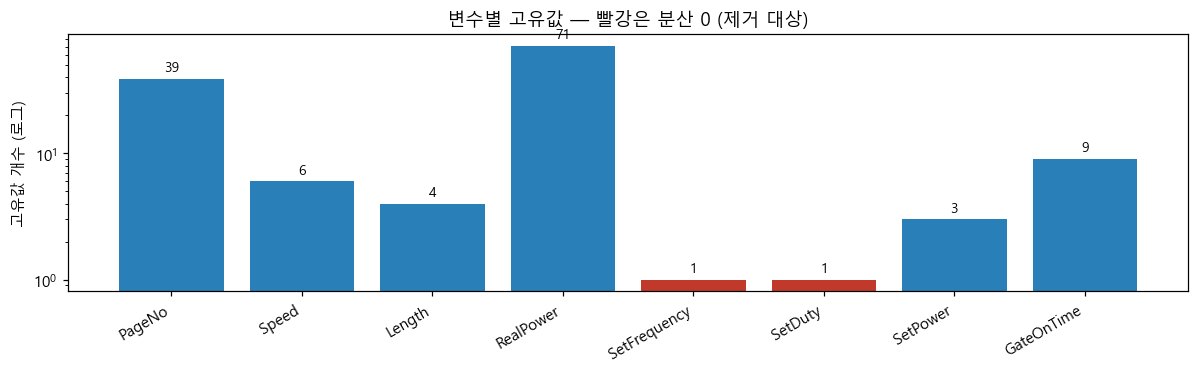

제거 대상: ['SetFrequency', 'SetDuty']
RealPower 최소: 0 → 미발광 구간 존재


In [3]:
tr0 = RAW['train']
cols = ['PageNo','Speed','Length','RealPower','SetFrequency','SetDuty','SetPower','GateOnTime']
nuq = tr0[cols].nunique()

fig, ax = plt.subplots(figsize=(11,3.5))
bars = ax.bar(range(len(nuq)), nuq.values,
              color=['#c0392b' if v==1 else '#2980b9' for v in nuq.values])
ax.set_xticks(range(len(nuq))); ax.set_xticklabels(nuq.index, rotation=30, ha='right')
ax.set_yscale('log'); ax.set_ylabel('고유값 개수 (로그)')
ax.set_title('변수별 고유값 — 빨강은 분산 0 (제거 대상)')
for i, v in enumerate(nuq.values):
    ax.text(i, v*1.15, str(v), ha='center', fontsize=9)
plt.tight_layout(); plt.show()

print('제거 대상:', [c for c in cols if tr0[c].nunique()==1])
print('RealPower 최소:', tr0['RealPower'].min(), '→ 미발광 구간 존재')

**읽는 법**

- **SetFrequency(1000), SetDuty(100)** — 고유값 1개. 분산 0이라 제거한다.
- **RealPower 고유값 71개** — 13만 행에 71가지. 연속 센서값이 아니라 **약 25W 단위로 이산화**돼 있다.
  뒤에서 규격 폭 ±80이 서너 칸밖에 안 된다는 뜻이 된다.
- **RealPower 최소 0** — 출력이 아예 안 나간 구간이 있다. 버리지 않고 플래그로 표시한다.

## 3. 설정값은 독립 변수가 아니라 레시피다

Speed, Length, SetPower, GateOnTime이 각각 따로 움직이는지 확인한다.
네 변수가 독립이면 6×4×3×9 = 648가지 조합이 가능하다.

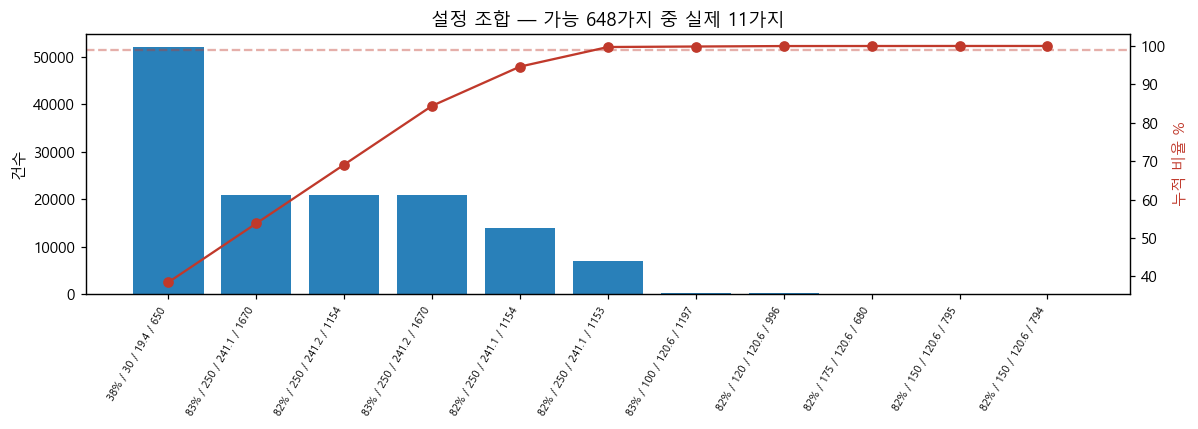

조합 11가지 / 상위 6개가 99.72%


In [4]:
combo = (tr0.groupby(['SetPower','Speed','Length','GateOnTime'])
             .size().reset_index(name='건수').sort_values('건수', ascending=False))
combo['비율%'] = (combo['건수']/len(tr0)*100).round(2)
combo['누적%'] = combo['비율%'].cumsum().round(2)

fig, ax = plt.subplots(figsize=(11,4))
lbl = [f"{r.SetPower}% / {r.Speed} / {r.Length} / {r.GateOnTime}" for r in combo.itertuples()]
ax.bar(range(len(combo)), combo['건수'], color='#2980b9')
ax2 = ax.twinx(); ax2.plot(range(len(combo)), combo['누적%'], 'o-', color='#c0392b', lw=1.5)
ax2.set_ylabel('누적 비율 %', color='#c0392b'); ax2.axhline(99, ls='--', color='#c0392b', alpha=.4)
ax.set_xticks(range(len(combo))); ax.set_xticklabels(lbl, rotation=60, ha='right', fontsize=7)
ax.set_ylabel('건수'); ax.set_title(f'설정 조합 — 가능 648가지 중 실제 {len(combo)}가지')
plt.tight_layout(); plt.show()

print(f'조합 {len(combo)}가지 / 상위 6개가 {combo["누적%"].iloc[5]}%')

**발견 ①  설정값 5개가 사실상 하나다**

648가지 중 **실제로는 11가지**만 나타나고, 그중 **상위 6개가 99.7%**를 차지한다.

| SetPower | Speed | Length | GateOnTime | 건수 | 비율 |
|---|---|---|---|---|---|
| 38 | 30 | 19.4 | 650 | 52,215 | 38.5% |
| 83 | 250 | 241.1 | 1670 | 20,806 | 15.3% |
| 82 | 250 | 241.2 | 1154 | 20,790 | 15.3% |
| 83 | 250 | 241.2 | 1670 | 20,790 | 15.3% |
| 82 | 250 | 241.1 | 1154 | 13,860 | 10.2% |
| 82 | 250 | 241.1 | 1153 | 6,930 | 5.1% |
| **나머지 5가지** | | | | **368** | **0.3%** |

하위 5가지는 Length가 전부 120.6이고 건수가 3~16건이다. **2022-03-24 하루 3시간에만 나타난다.**
조건을 바꿔본 시험 운전으로 보이며(추정), 정상 기준에서 제외할 수 있도록 플래그로 표시한다.

## 4. 전처리 — 버리지 않고 구조를 복원한다

이 데이터는 결측도 중복도 없다. 그래서 **청소할 게 없다.**
전처리의 핵심은 **원본에 없는 구조를 만들어내는 것**이다.

| 작업 | 내용 | 근거 |
|---|---|---|
| 제거 | SetFrequency, SetDuty | 분산 0 |
| 파생 | gap = RealPower − 2000×SetPower(%) | 가이드북 58쪽 규격식 |
| 파생 | margin = 규격선까지 남은 여유 | 현장 공차 여유 개념 |
| 플래그 | dead (RealPower=0) | 제거 아님 — 출력 0 자체가 이상 |
| 플래그 | testcond (Length=120.6) | 3/24 시험 조건 |
| 구조 | seg (1시간 이상 공백 = 조각 경계) | 데이터가 연속이 아님 |
| 구조 | pos (조각 내 39주기 위치) | 부분군 정의에 필요 |

In [5]:
USL, LSL = 80.0, -80.0

def prep(df):
    d = df.rename(columns=lambda c: c.strip()).copy()
    d = d.drop(columns=[c for c in ['SetFrequency','SetDuty'] if c in d.columns])
    d['t'] = pd.to_datetime(d['WorkingTime'])

    d['gap']    = d['RealPower'].astype(float) - d['SetPower'].astype(float)*20
    d['margin'] = np.minimum(USL - d['gap'], d['gap'] - LSL)

    d['dead']     = (d['RealPower'] == 0).astype(int)
    d['testcond'] = (d['Length'] == 120.6).astype(int)

    d['seg'] = (d['t'].diff().dt.total_seconds() > 3600).cumsum()
    d['pos'] = d.groupby('seg').cumcount() % 39 + 1
    d['cyc'] = d['seg'].astype(str) + '_' + (d.groupby('seg').cumcount()//39).astype(str)
    return d

TR  = prep(RAW['train'])
OK1 = prep(RAW['ok1']); OK2 = prep(RAW['ok2'])
NG3 = prep(RAW['ng3']); NG4 = prep(RAW['ng4'])

BASE_N = TR[(TR.dead==0) & (TR.testcond==0)]      # 정상 기준 데이터

print(f'조각 {TR.seg.nunique()}개 | 사이클 {TR.cyc.nunique()}개 | pos==PageNo {(TR.pos==TR.PageNo).all()}')
print(f'dead {TR.dead.sum()}건 | testcond {TR.testcond.sum()}건 | 정상기준 {len(BASE_N):,}행')
print(f'수집 기간 {TR.t.min().date()} ~ {TR.t.max().date()}')
print(f'수집 주기 최빈 {TR.t.diff().dt.total_seconds().round(2).mode()[0]}초')

조각 147개 | 사이클 3481개 | pos==PageNo True
dead 39건 | testcond 368건 | 정상기준 135,352행
수집 기간 2022-01-08 ~ 2022-07-29
수집 주기 최빈 1.72초


**발견 ②  조각 147개, 전부 39의 배수**

`pos == PageNo`가 True라는 것은 **147개 조각 어디에서도 사이클이 어긋나지 않았다**는 뜻이다.
즉 데이터가 사이클 단위로 잘려서 수집됐다. 이 덕분에 사이클을 부분군으로 쓸 수 있다.

> ⚠️ **가이드북 불일치 ②③**
> - 기간: 가이드북 7~9월 → **실제 2022-01-08 ~ 07-29**
> - 주기: 가이드북 약 3초 → **실제 약 1.71초**

## 5. 39포인트 구조 — 자리마다 다른 설비다

숫자 표로 보면 39줄이라 읽기 어렵다. **자리별 설정을 색으로** 그린다.

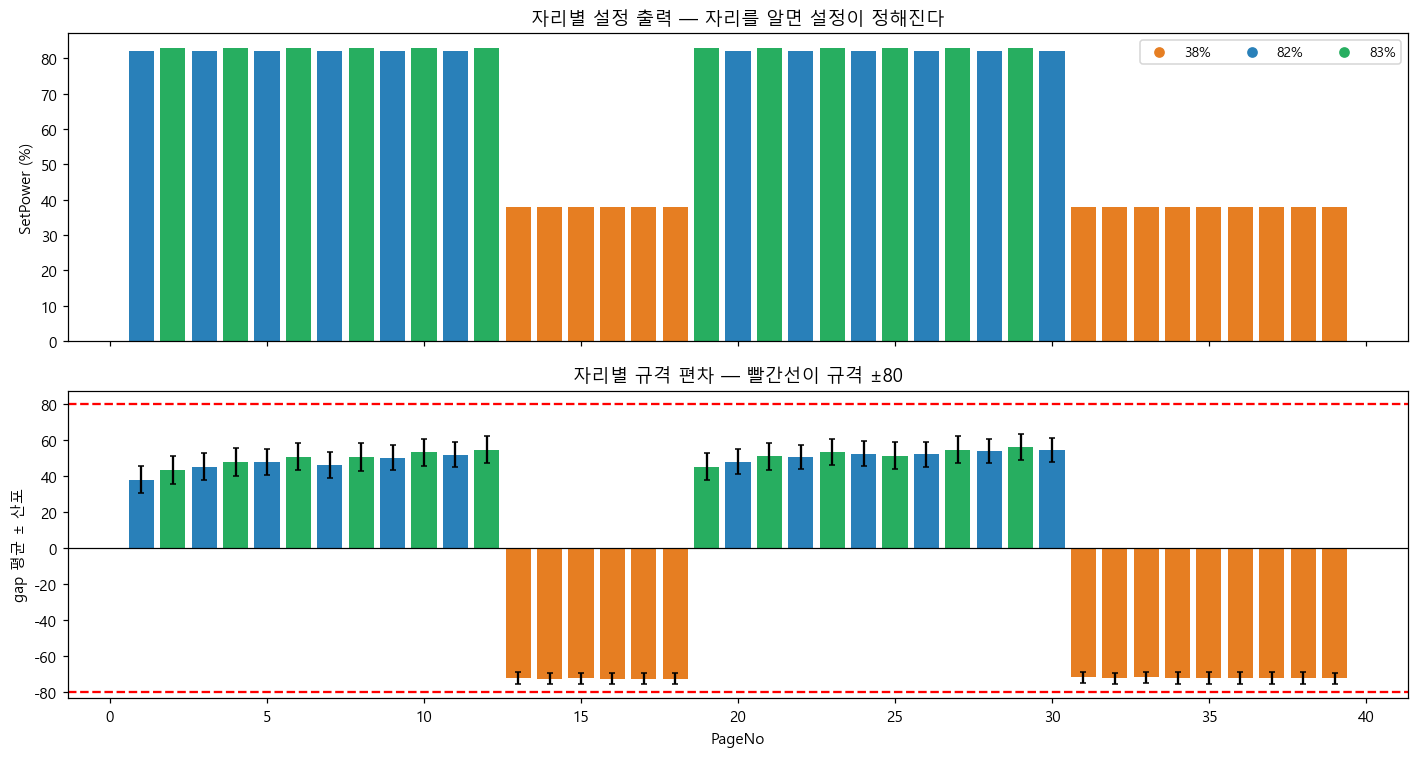

(PageNo, SetPower) 조합 39개 / PageNo 39개


In [6]:
prof = BASE_N.groupby('PageNo').agg(
    SetPower=('SetPower','first'), Speed=('Speed','nunique'),
    gap평균=('gap','mean'), gap산포=('gap','std'), 건수=('gap','size')).reset_index()
prof['그룹'] = prof['Speed'].map({4:'A(82%·조건가변)', 2:'B(83%·조건가변)', 1:'C(조건고정)'})

fig, axes = plt.subplots(2,1, figsize=(13,7), sharex=True)
col = {38:'#e67e22', 82:'#2980b9', 83:'#27ae60'}
cs  = [col[s] for s in prof['SetPower']]

axes[0].bar(prof['PageNo'], prof['SetPower'], color=cs)
axes[0].set_ylabel('SetPower (%)'); axes[0].set_title('자리별 설정 출력 — 자리를 알면 설정이 정해진다')
for sp, c_ in col.items():
    axes[0].scatter([],[],color=c_,label=f'{sp}%')
axes[0].legend(ncol=3, fontsize=9)

axes[1].bar(prof['PageNo'], prof['gap평균'], yerr=prof['gap산포'], capsize=2, color=cs)
axes[1].axhline(USL, ls='--', color='r'); axes[1].axhline(LSL, ls='--', color='r')
axes[1].axhline(0, color='k', lw=.8)
axes[1].set_ylabel('gap 평균 ± 산포'); axes[1].set_xlabel('PageNo')
axes[1].set_title('자리별 규격 편차 — 빨간선이 규격 ±80')
plt.tight_layout(); plt.show()

print(f"(PageNo, SetPower) 조합 {len(set(zip(BASE_N.PageNo, BASE_N.SetPower)))}개 "
      f"/ PageNo {BASE_N.PageNo.nunique()}개")

**발견 ③  자리당 설정이 정확히 하나**

`(PageNo, SetPower)` 조합이 **39개 = PageNo 개수**다.
자리를 알면 출력이 하나로 정해진다.

| 그룹 | PageNo | SetPower | 조건 |
|---|---|---|---|
| A | 1,3,5,7,9,11 / 20,22,24,26,28,30 | 82% | 가변 (Speed 4종) |
| B | 2,4,6,8,10,12 / 21,23,25,27,29 | 83% | 가변 (Speed 2종) |
| C | 13~18, 31~39 | 38% | 고정 |
| C | **19** | **83%** | 고정 (저출력 블록 사이에 혼자 끼어 있음) |

**이것이 판정 근거가 된다.** 39개 조합을 벗어난 설정이 오면 그 자체가 이상이다.
그리고 이 규칙은 **학습 데이터만으로 도출된다** — 테스트셋을 보지 않아도 세울 수 있다.

## 6. 규격 안 어디에 있는가 — 이 설비의 첫 번째 문제

gap 분포를 그리면 한눈에 보인다. 빨간 점선이 규격 ±80이다.

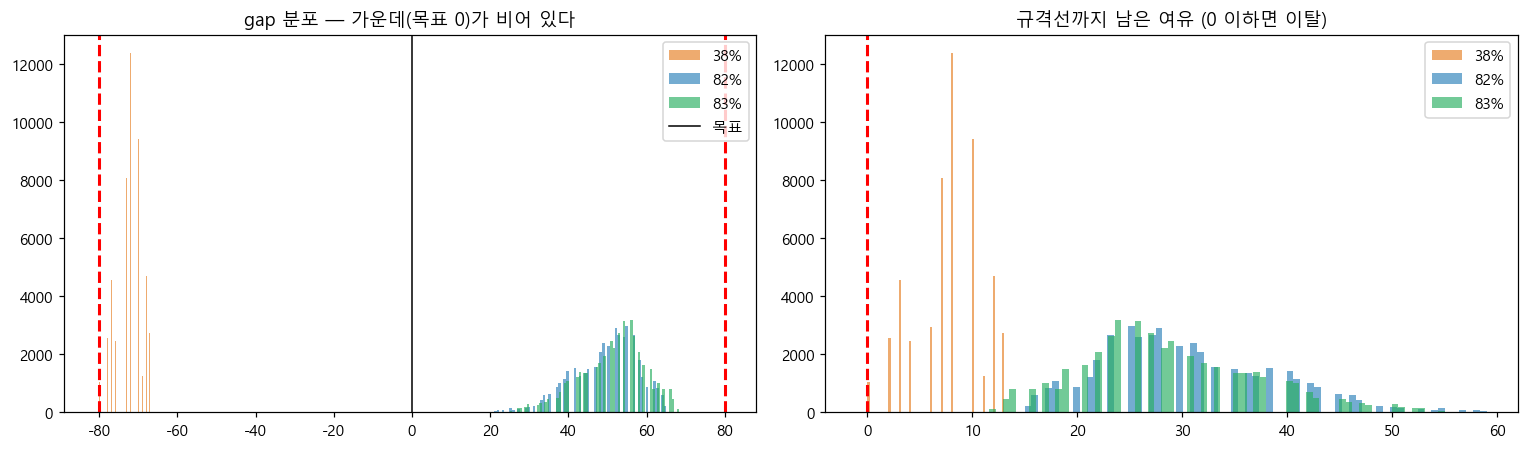

           size   mean   std   min   max  하한여유σ  상한여유σ
SetPower                                              
38        52200 -72.30  3.17 -81.0 -67.0   2.43  48.04
82        41568  49.45  8.31  21.0  67.0  15.58   3.68
83        41584  51.17  8.42  25.0  69.0  15.58   3.42


In [7]:
fig, axes = plt.subplots(1,2, figsize=(14,4.2))

for sp, g in BASE_N.groupby('SetPower'):
    axes[0].hist(g['gap'], bins=70, alpha=.65, label=f'{sp}%', color=col[sp])
axes[0].axvline(USL, ls='--', color='r', lw=2); axes[0].axvline(LSL, ls='--', color='r', lw=2)
axes[0].axvline(0, color='k', lw=1, label='목표')
axes[0].set_title('gap 분포 — 가운데(목표 0)가 비어 있다'); axes[0].legend()

for sp, g in BASE_N.groupby('SetPower'):
    axes[1].hist(g['margin'], bins=70, alpha=.65, label=f'{sp}%', color=col[sp])
axes[1].axvline(0, ls='--', color='r', lw=2)
axes[1].set_title('규격선까지 남은 여유 (0 이하면 이탈)'); axes[1].legend()
plt.tight_layout(); plt.show()

summ = BASE_N.groupby('SetPower')['gap'].agg(['size','mean','std','min','max']).round(2)
summ['하한여유σ'] = ((summ['mean'] - LSL)/summ['std']).round(2)
summ['상한여유σ'] = ((USL - summ['mean'])/summ['std']).round(2)
print(summ.to_string())

**발견 ④  정상인데도 규격 벽에 붙어 있다**

| SetPower | gap 평균 | 산포 | 하한까지 | 상한까지 |
|---|---|---|---|---|
| 38% | **−72.30** | 3.17 | **0.60σ** ⚠️ | 12.6σ |
| 82% | +49.45 | 8.31 | 4.3σ | **1.03σ** ⚠️ |
| 83% | +51.17 | 8.42 | 4.4σ | **0.93σ** ⚠️ |

**목표값(gap=0) 근처에 아무도 없다.** 두 무리가 규격 양 끝에 붙어 있다.

- **저출력 15자리는 하한까지 0.6σ** — 평소 흔들림의 절반만 더 떨어져도 불합격
- **고출력 24자리는 상한까지 1σ** — 조금만 밀려도 초과

프레스로 치면 **공차 하한에 바짝 붙여서 계속 찍고 있는 상태**다.
지금은 통과하지만 조건이 조금만 나빠지면 불량이 쏟아진다.

## 7. 공정능력 지수 — 단기와 장기를 분리한다

| 지표 | 산포 기준 | 의미 |
|---|---|---|
| **Cp / Cpk** | 군내(사이클 안) | 순간 능력. 설비 자체의 정밀도 |
| **Pp / Ppk** | 전체 | 실제 능력. 시간 드리프트까지 포함 |

```
Cp  = (USL − LSL) / 6σ          산포만 본다
Cpk = min(USL−μ, μ−LSL) / 3σ    중심 이탈까지 본다
```

**부분군은 사이클(39포인트)**로 잡는다. 같은 자리를 연속 5사이클씩 묶는다.

In [8]:
def capability(d, by, k=5):
    v = d.sort_values([by,'seg']).copy()
    v['grp'] = v.groupby(by).cumcount() // k
    rows = []
    for key, g in v.groupby(by):
        mu   = g['gap'].mean()
        s_ov = g['gap'].std(ddof=1)
        s_wi = g.groupby('grp')['gap'].std(ddof=1).mean()
        if not np.isfinite(s_wi) or s_wi == 0: s_wi = s_ov
        rows.append({by: key, 'n': len(g), 'μ': mu,
                     'σ_군내': s_wi, 'σ_전체': s_ov, '배수': s_ov/s_wi,
                     'Cp':  (USL-LSL)/(6*s_wi),
                     'Cpk': min((USL-mu)/(3*s_wi), (mu-LSL)/(3*s_wi)),
                     'Pp':  (USL-LSL)/(6*s_ov),
                     'Ppk': min((USL-mu)/(3*s_ov), (mu-LSL)/(3*s_ov)),
                     '실측이탈률': g['gap'].abs().gt(80).mean()})
    return pd.DataFrame(rows).round(4)

cap_mode = capability(BASE_N, 'SetPower')
print(cap_mode.to_string(index=False))

 SetPower     n        μ   σ_군내   σ_전체      배수      Cp    Cpk     Pp    Ppk  실측이탈률
       38 52200 -72.2983 0.2921 3.1652 10.8342 91.2782 8.7875 8.4250 0.8111 0.0004
       82 41568  49.4550 3.8674 8.3051  2.1475  6.8953 2.6327 3.2109 1.2260 0.0000
       83 41584  51.1737 3.9239 8.4165  2.1450  6.7960 2.4488 3.1684 1.1417 0.0000


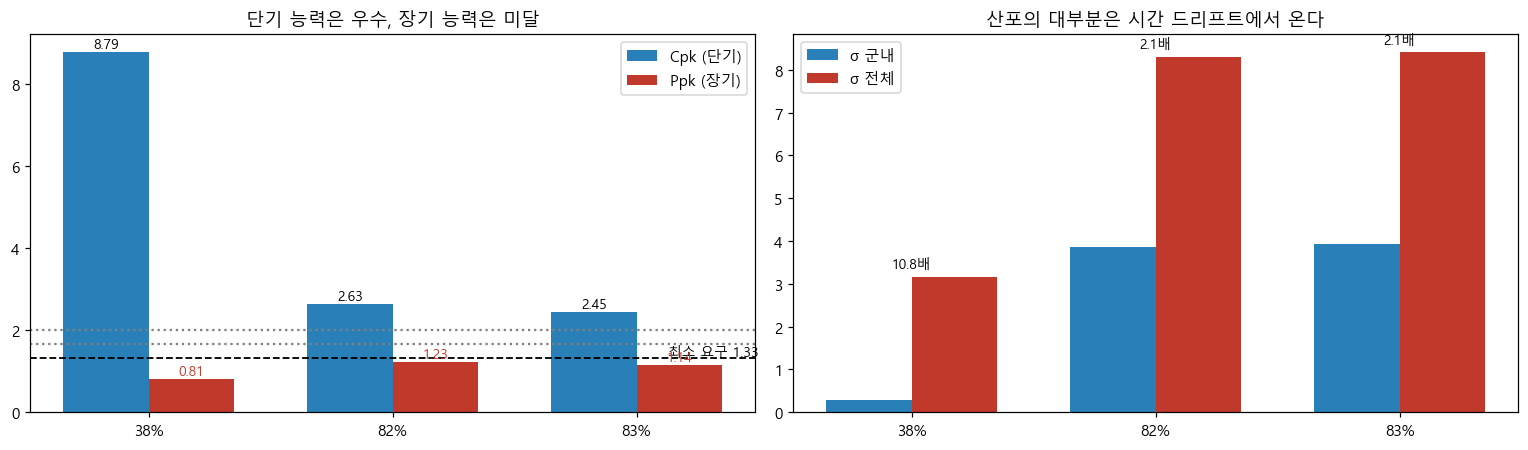

In [9]:
fig, axes = plt.subplots(1,2, figsize=(14,4.2))

x = np.arange(len(cap_mode)); w = 0.35
axes[0].bar(x-w/2, cap_mode['Cpk'], w, label='Cpk (단기)', color='#2980b9')
axes[0].bar(x+w/2, cap_mode['Ppk'], w, label='Ppk (장기)', color='#c0392b')
axes[0].axhline(1.33, ls='--', color='k', lw=1.2)
axes[0].text(len(x)-0.5, 1.38, '최소 요구 1.33', ha='right', fontsize=9)
axes[0].axhline(1.67, ls=':', color='gray'); axes[0].axhline(2.0, ls=':', color='gray')
axes[0].set_xticks(x); axes[0].set_xticklabels([f'{s}%' for s in cap_mode['SetPower']])
axes[0].set_title('단기 능력은 우수, 장기 능력은 미달'); axes[0].legend()
for i,(a,b) in enumerate(zip(cap_mode['Cpk'], cap_mode['Ppk'])):
    axes[0].text(i-w/2, a+.1, f'{a:.2f}', ha='center', fontsize=9)
    axes[0].text(i+w/2, b+.1, f'{b:.2f}', ha='center', fontsize=9, color='#c0392b')

axes[1].bar(x-w/2, cap_mode['σ_군내'], w, label='σ 군내', color='#2980b9')
axes[1].bar(x+w/2, cap_mode['σ_전체'], w, label='σ 전체', color='#c0392b')
axes[1].set_xticks(x); axes[1].set_xticklabels([f'{s}%' for s in cap_mode['SetPower']])
axes[1].set_title('산포의 대부분은 시간 드리프트에서 온다'); axes[1].legend()
for i, r in cap_mode.iterrows():
    axes[1].text(i, r['σ_전체']+.2, f"{r['배수']:.1f}배", ha='center', fontsize=9)
plt.tight_layout(); plt.show()

**발견 ⑤  단기는 완벽, 장기는 부적합**

| SetPower | σ_군내 | σ_전체 | 배수 | **Cpk** | **Ppk** | 판정 |
|---|---|---|---|---|---|---|
| 38% | 0.373 | 3.165 | **8.5배** | 6.88 | **0.811** | ❌ |
| 82% | 4.642 | 8.354 | 1.8배 | 2.19 | **1.216** | ❌ |
| 83% | 3.929 | 8.457 | 2.2배 | 2.44 | **1.134** | ❌ |

**같은 자리, 같은 데이터인데 단기와 장기가 3~8배 벌어진다.**

- **Cpk 2.2~6.9** — 식스시그마 수준(2.0)을 넘는다. 설비 정밀도는 충분하다.
- **Ppk 0.81~1.22** — 최소 요구(1.33)에 미달한다. 실제 능력은 부족하다.

**해석**: 5사이클 안에서는 편차가 0.19~1.06밖에 안 된다. 순간순간은 완벽하다.
그런데 전체로 보면 3.1~8.5다. **산포의 90% 이상이 시간 드리프트에서 온다.**

**처방이 달라진다.** 설비 정밀도를 개선할 게 아니라 **시간에 따른 중심 이동을 관리**해야 한다.

## 7-1. 정규성 검정 — Cpk를 확률로 읽어도 되는가

Cp/Cpk/Pp/Ppk는 **정규분포를 전제**한다.
"Cpk 1.33이면 불량률 63ppm" 같은 환산이 정규 가정 위에서 성립하기 때문이다.

전제가 깨지면 지수를 확률로 해석할 수 없다. 검정한다.

 SetPower     n     왜도     첨도  Shapiro_W Shapiro_p    AD통계  AD임계(5%)  고유값수
       38 52200 -0.390 -0.436     0.9454  1.39e-39 1073.16      0.79    12
       82 41568 -0.576  0.039     0.9681  6.07e-32  354.01      0.79    37
       83 41584 -0.510 -0.097     0.9711  1.27e-30  330.16      0.79    36


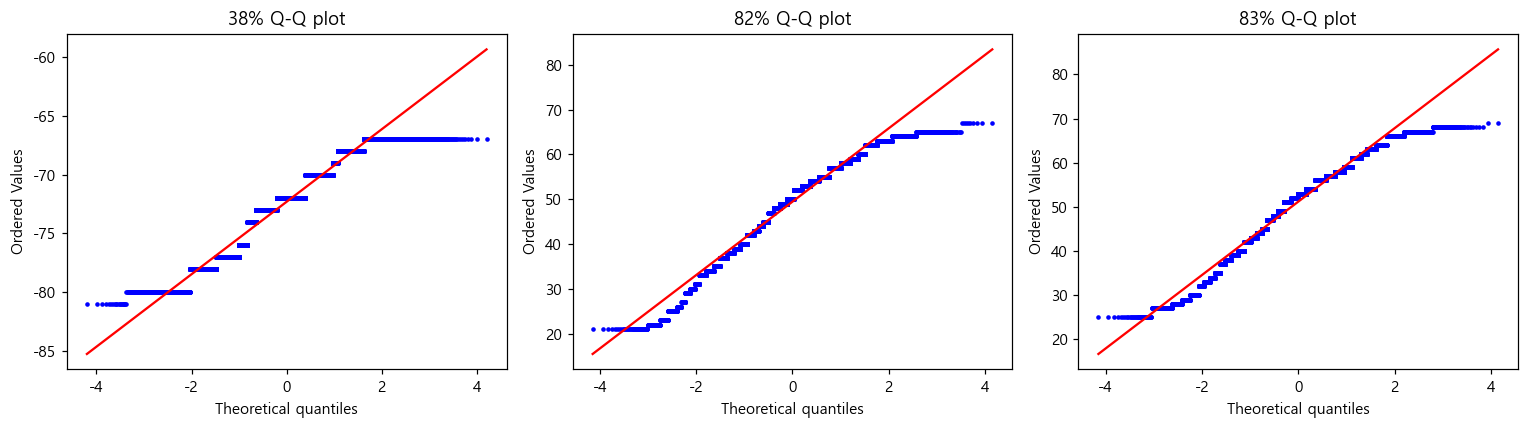

In [16]:
from scipy import stats

rows = []
for sp, g in BASE_N.groupby('SetPower'):
    x = g['gap'].values
    smp = np.random.default_rng(42).choice(x, min(5000, len(x)), replace=False)
    W, p_sw = stats.shapiro(smp)
    ad = stats.anderson(x, dist='norm')
    rows.append({
        'SetPower': sp, 'n': len(x),
        '왜도': round(stats.skew(x), 3),
        '첨도': round(stats.kurtosis(x), 3),
        'Shapiro_W': round(W, 4),
        'Shapiro_p': f'{p_sw:.2e}',
        'AD통계': round(ad.statistic, 2),
        'AD임계(5%)': round(ad.critical_values[2], 2),
        '고유값수': g['gap'].nunique(),
    })
NORM = pd.DataFrame(rows)
print(NORM.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (sp, g) in zip(axes, BASE_N.groupby('SetPower')):
    stats.probplot(g['gap'].values, dist='norm', plot=ax)
    ax.set_title(f'{sp}% Q-Q plot'); ax.get_lines()[0].set_markersize(2)
plt.tight_layout(); plt.show()

**결과 — 정규성 기각**

| SetPower | n | 왜도 | 첨도 | Shapiro W | Shapiro p | AD 통계 | AD 임계(5%) | gap 고유값 |
|---|---|---|---|---|---|---|---|---|
| 38% | 52,200 | −0.390 | −0.436 | 0.9454 | **1.39e-39** | 1073.16 | 0.79 | **12** |
| 82% | 41,568 | −0.576 | +0.039 | 0.9681 | **6.07e-32** | 354.01 | 0.79 | 37 |
| 83% | 41,584 | −0.510 | −0.097 | 0.9711 | **1.27e-30** | 330.16 | 0.79 | 36 |

Shapiro p가 전부 1e-30 이하이고, Anderson–Darling 통계량이 임계값의 **400~1300배**다.

**다만 표본 크기 효과를 고려해야 한다.**
4만~5만 행에서는 아주 작은 이탈도 통계적으로 유의하게 나온다.
p값만으로 "정규가 아니다"라고 하면 반박될 수 있다.

**더 결정적인 근거는 이산성이다.**

- 왜도 −0.39~−0.58, 첨도 −0.44~+0.04 → **정규에서 크게 벗어나지 않는다**
- gap 고유값이 **12~37개** → 5만 행에 12가지 값. 연속분포로 다룰 수 없다
- Q-Q plot이 계단 모양이고 양끝이 꺾인다 → **분포의 꼬리가 잘려 있다**

> **결론** — Cpk/Ppk를 **불량률로 환산하지 않고 비교 지표로만** 사용한다.

## 7-2. 비모수 공정능력 — 전제 없이도 같은 결론인가

정규성이 깨졌으므로, 정규 전제 없이 계산되는 방식으로 다시 구한다.
**ISO 21747** 방식은 실제 분포의 백분위수(0.135% / 50% / 99.865%)를 사용한다.

```
Ppk_비모수 = min( (USL − P50)/(P99.865 − P50),  (P50 − LSL)/(P50 − P0.135) )
```

두 방식이 같은 결론을 주면 정규성 문제가 판정을 흔들지 않는다는 뜻이다.

 SetPower  Ppk_정규  Ppk_비모수    차이    실측이탈률  정규가정이탈률     과대배수
       38   0.811      1.0 0.189 0.000364 0.007482     20.6
       82   1.226      2.0 0.774 0.000000 0.000118 117592.8
       83   1.142      1.8 0.658 0.000000 0.000307 307435.3


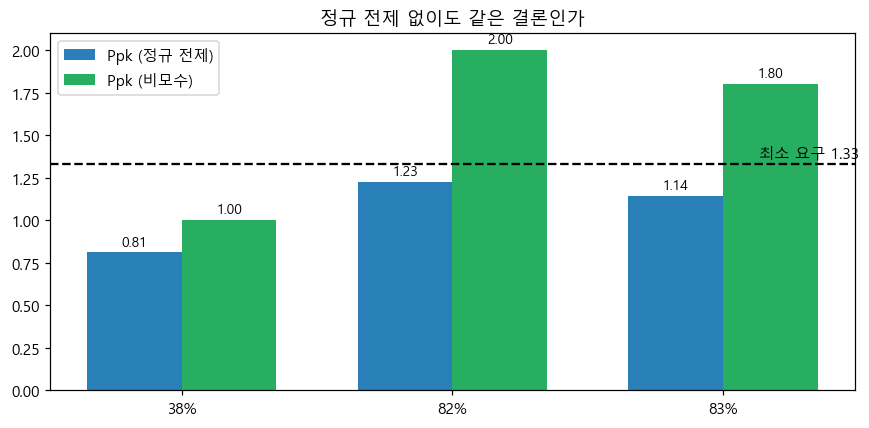

In [17]:
def cap_nonparam(g, USL=80.0, LSL=-80.0):
    """ISO 21747 방식 — 정규 전제 없이 실제 분포의 백분위수 사용"""
    p_lo, p_med, p_hi = np.percentile(g['gap'], [0.135, 50, 99.865])
    Pp  = (USL - LSL) / (p_hi - p_lo)
    return Pp, min((USL-p_med)/(p_hi-p_med), (p_med-LSL)/(p_med-p_lo))

rows = []
for sp, g in BASE_N.groupby('SetPower'):
    Pp_np, Ppk_np = cap_nonparam(g)
    mu, sd = g['gap'].mean(), g['gap'].std()
    Ppk_n  = min((USL-mu)/(3*sd), (mu-LSL)/(3*sd))
    obs = g['gap'].abs().gt(80).mean()
    exp = stats.norm.sf((USL-mu)/sd) + stats.norm.cdf((LSL-mu)/sd)
    rows.append({'SetPower': sp,
                 'Ppk_정규': round(Ppk_n, 3), 'Ppk_비모수': round(Ppk_np, 3),
                 '차이': round(Ppk_np-Ppk_n, 3),
                 '실측이탈률': round(obs, 6), '정규가정이탈률': round(exp, 6),
                 '과대배수': round(exp/max(obs, 1e-9), 1)})
NP = pd.DataFrame(rows)
print(NP.to_string(index=False))

fig, ax = plt.subplots(figsize=(8,4))
x = np.arange(len(NP)); w = 0.35
ax.bar(x-w/2, NP['Ppk_정규'],   w, label='Ppk (정규 전제)', color='#2980b9')
ax.bar(x+w/2, NP['Ppk_비모수'], w, label='Ppk (비모수)',    color='#27ae60')
ax.axhline(1.33, ls='--', color='k'); ax.text(len(x)-.5, 1.37, '최소 요구 1.33', ha='right')
ax.set_xticks(x); ax.set_xticklabels([f'{s}%' for s in NP['SetPower']])
ax.set_title('정규 전제 없이도 같은 결론인가'); ax.legend()
for i, r in NP.iterrows():
    ax.text(i-w/2, r['Ppk_정규']+.04,   f"{r['Ppk_정규']:.2f}",   ha='center', fontsize=9)
    ax.text(i+w/2, r['Ppk_비모수']+.04, f"{r['Ppk_비모수']:.2f}", ha='center', fontsize=9)
plt.tight_layout(); plt.show()

**결과 — 저출력만 일치, 고출력은 뒤집힘**

| SetPower | Ppk 정규 | Ppk 비모수 | 차이 | 실측 이탈률 | 정규 가정 이탈률 | 과대 배수 |
|---|---|---|---|---|---|---|
| **38%** | 0.811 | **1.000** | +0.189 | 0.000364 | 0.007482 | **20.6배** |
| 82% | 1.226 | **2.000** | +0.774 | **0** | 0.000118 | 117,593배 |
| 83% | 1.142 | **1.800** | +0.658 | **0** | 0.000307 | 307,435배 |

**저출력(38%)은 두 방식 모두 기준 1.33에 미달한다.** 결론이 일치한다.

**고출력은 판정이 갈린다.** 정규 전제로는 미달(1.14~1.23)인데 비모수로는 우수(1.80~2.00)다.

**원인은 분포 꼬리의 절단이다.**
고출력은 4만여 건에서 **규격 이탈이 0건**이다. gap 최대가 67에서 멈춘다(규격 80).
정규분포는 꼬리가 무한히 뻗으므로 "1만 건에 1건은 나와야 한다"고 계산하지만,
실제 분포는 그 지점에서 잘려 있다. 과대 배수가 10만 배를 넘는 이유다.

> **결론**
> - 저출력: 두 방식 일치. **기준 미달 확정.** 본 분석의 핵심 대상이다.
> - 고출력: 판정이 갈림. 절단 이유(설비 제어 / 데이터 처리 / 우연)를 확인하지 못해
>   **어느 값을 채택할지 결정하지 않는다.**

## 8. 자리별 취약도 — 어디부터 조치할 것인가

Ppk가 낮은 순으로 정렬하면 우선순위가 나온다.

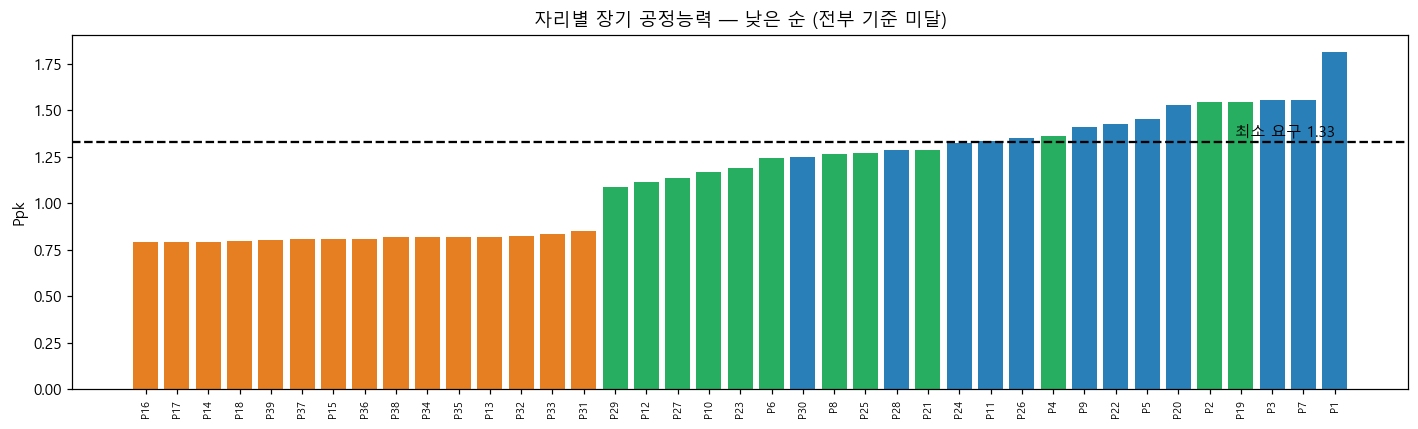

[Ppk 하위 10]
 PageNo  SetPower        μ   σ_군내   σ_전체     Cpk    Ppk
     16        38 -72.5555 0.4042 3.1351  6.1396 0.7915
     17        38 -72.5736 0.3789 3.1219  6.5335 0.7929
     14        38 -72.5365 0.3220 3.1317  7.7263 0.7944
     18        38 -72.5744 0.3441 3.1009  7.1939 0.7982
     39        38 -72.4480 0.2491 3.1287 10.1064 0.8046
     37        38 -72.3193 0.2968 3.1637  8.6251 0.8093
     15        38 -72.3408 0.4058 3.1539  6.2922 0.8095
     36        38 -72.2655 0.2806 3.1817  9.1888 0.8103
     38        38 -72.1580 0.2811 3.2006  9.2994 0.8167
     34        38 -72.2161 0.3128 3.1720  8.2958 0.8180


In [10]:
cap_p = capability(BASE_N, 'PageNo')
cap_p['SetPower'] = BASE_N.groupby('PageNo')['SetPower'].first().values
cap_p = cap_p.sort_values('Ppk')

fig, ax = plt.subplots(figsize=(13,4))
cs = [col[s] for s in cap_p['SetPower']]
ax.bar(range(len(cap_p)), cap_p['Ppk'], color=cs)
ax.axhline(1.33, ls='--', color='k'); ax.text(len(cap_p)-1, 1.36, '최소 요구 1.33', ha='right')
ax.set_xticks(range(len(cap_p)))
ax.set_xticklabels([f"P{int(p)}" for p in cap_p['PageNo']], rotation=90, fontsize=7)
ax.set_ylabel('Ppk'); ax.set_title('자리별 장기 공정능력 — 낮은 순 (전부 기준 미달)')
plt.tight_layout(); plt.show()

print('[Ppk 하위 10]')
print(cap_p.head(10)[['PageNo','SetPower','μ','σ_군내','σ_전체','Cpk','Ppk']].to_string(index=False))

**발견 ⑥  하위 15자리가 전부 38% 모드**

Ppk 최하위 15개가 **저출력 자리 15개 전부**다 (0.79~0.85).
16위부터가 83% 자리(1.08~1.18)다.

**자리 간 차이는 거의 없다.** 폭이 0.06뿐이다.
즉 "특정 자리가 나쁘다"가 아니라 **"저출력 모드 전체가 균일하게 취약하다"**가 맞는 진단이다.

이것은 개별 용접 헤드 문제가 아니라 **공통 요인**을 가리킨다.

## 8-1. 자리별 산포 차이는 무엇 때문인가

자리별 σ에 차이가 있다. 원인이 **설비 차이**인지 **측정 해상도**인지 확인한다.

RealPower가 정수이므로 gap도 정수 격자 위에 놓인다.
자리마다 나타나는 값의 개수가 다르면 그것이 σ 차이를 만들 수 있다.

 PageNo    n  고유값수  최소간격  상위2값비중  σ_전체  gap평균
     13 3480    11   1.0   0.438 3.185 -72.16
     14 3480    12   1.0   0.432 3.132 -72.54
     15 3480    12   1.0   0.427 3.154 -72.34
     16 3480    12   1.0   0.439 3.135 -72.56
     17 3480    12   1.0   0.442 3.122 -72.57
     18 3480    12   1.0   0.447 3.101 -72.57
     31 3480    11   1.0   0.454 3.195 -71.82
     32 3480    11   1.0   0.445 3.034 -72.51
     33 3480    11   1.0   0.446 3.232 -71.90
     34 3480    11   1.0   0.423 3.172 -72.22
     35 3480    11   1.0   0.431 3.212 -72.10
     36 3480    11   1.0   0.417 3.182 -72.27
     37 3480    11   1.0   0.414 3.164 -72.32
     38 3480    11   1.0   0.427 3.201 -72.16
     39 3480    11   1.0   0.434 3.129 -72.45


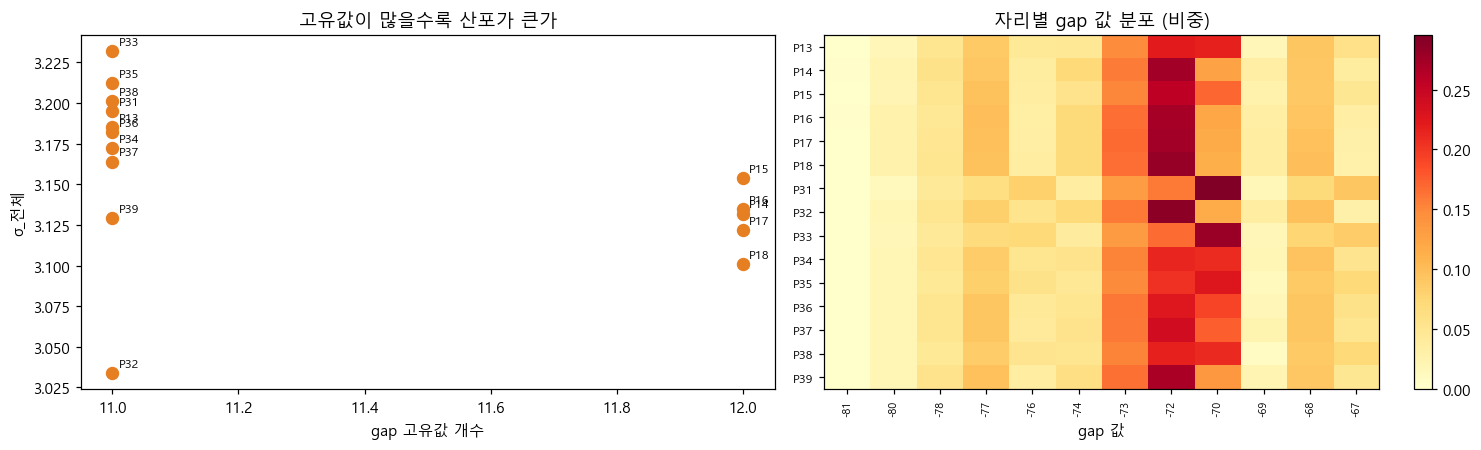


고유값 범위: 11 ~ 12
최소간격 최빈: [1.]
고유값수-σ 상관: -0.407


In [25]:
lo = BASE_N[BASE_N.SetPower==38]

rows = []
for p, g in lo.groupby('PageNo'):
    vals = np.sort(g['gap'].unique())
    step = np.diff(vals).min() if len(vals) > 1 else np.nan
    top2 = g['gap'].value_counts(normalize=True).head(2).sum()
    rows.append({'PageNo': p, 'n': len(g),
                 '고유값수': len(vals),
                 '최소간격': round(step, 2),
                 '상위2값비중': round(top2, 3),
                 'σ_전체': round(g['gap'].std(), 3),
                 'gap평균': round(g['gap'].mean(), 2)})
RES = pd.DataFrame(rows)
print(RES.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
axes[0].scatter(RES['고유값수'], RES['σ_전체'], s=60, color='#e67e22')
for r in RES.itertuples():
    axes[0].annotate(f'P{r.PageNo}', (r.고유값수, r.σ_전체),
                     xytext=(4,4), textcoords='offset points', fontsize=8)
axes[0].set_xlabel('gap 고유값 개수'); axes[0].set_ylabel('σ_전체')
axes[0].set_title('고유값이 많을수록 산포가 큰가')

piv = lo.pivot_table(index='PageNo', columns='gap', values='RealPower',
                     aggfunc='size', fill_value=0)
piv = piv.div(piv.sum(axis=1), axis=0)
im = axes[1].imshow(piv.values, aspect='auto', cmap='YlOrRd')
axes[1].set_xticks(range(len(piv.columns)))
axes[1].set_xticklabels([int(c) for c in piv.columns], rotation=90, fontsize=7)
axes[1].set_yticks(range(len(piv.index)))
axes[1].set_yticklabels([f'P{p}' for p in piv.index], fontsize=8)
axes[1].set_xlabel('gap 값'); axes[1].set_title('자리별 gap 값 분포 (비중)')
plt.colorbar(im, ax=axes[1])
plt.tight_layout(); plt.show()

print(f"\n고유값 범위: {RES['고유값수'].min()} ~ {RES['고유값수'].max()}")
print(f"최소간격 최빈: {RES['최소간격'].mode().values}")
print(f"고유값수-σ 상관: {RES['고유값수'].corr(RES['σ_전체']):.3f}")

**결과 — 해상도 가설은 기각된다**

```
gap 고유값 범위    11 ~ 12개   (차이 1개)
최소 간격          1.0         (정수 격자)
σ_전체 범위        3.03 ~ 3.23 (폭 0.20, 6%)
고유값수 ↔ σ 상관   −0.407      (음의 상관)
```

**상관이 음수다.** 고유값이 많은 자리(12개)가 오히려 σ가 작다.
→ **"고유값 개수가 산포를 만든다"는 가설은 성립하지 않는다.**

히트맵을 보면 실제 원인이 보인다. **자리마다 분포 중심이 미세하게 다르다.**
P31~P33은 −70 근처에 몰려 있고 나머지는 −72 근처다.
Ppk 순위에서 P31이 가장 높았던 것(0.8535)과 일치한다.

**다만 그 차이가 작다.** σ 폭이 0.20(6%)이고, 앞서 확인한 Ppk 폭 0.06,
월변화 폭 0.13과 같은 방향이다.

> **결론** — 자리 간 차이는 실무적으로 무시할 수준이다.
> **"특정 자리가 나쁘다"가 아니라 "저출력 15자리 전체가 균일하게 취약하다."**
> 부수적으로, 최소 간격 1과 고유값 11~12개는 §7-1의 이산성 근거를 보강한다.

## 9. 관리도 — 시간에 따라 중심이 움직이는가

Ppk가 낮은 이유가 시간 드리프트라면, 관리도에 그대로 나타나야 한다.
저출력(38%) 자리를 조각 단위로 묶어 그린다.

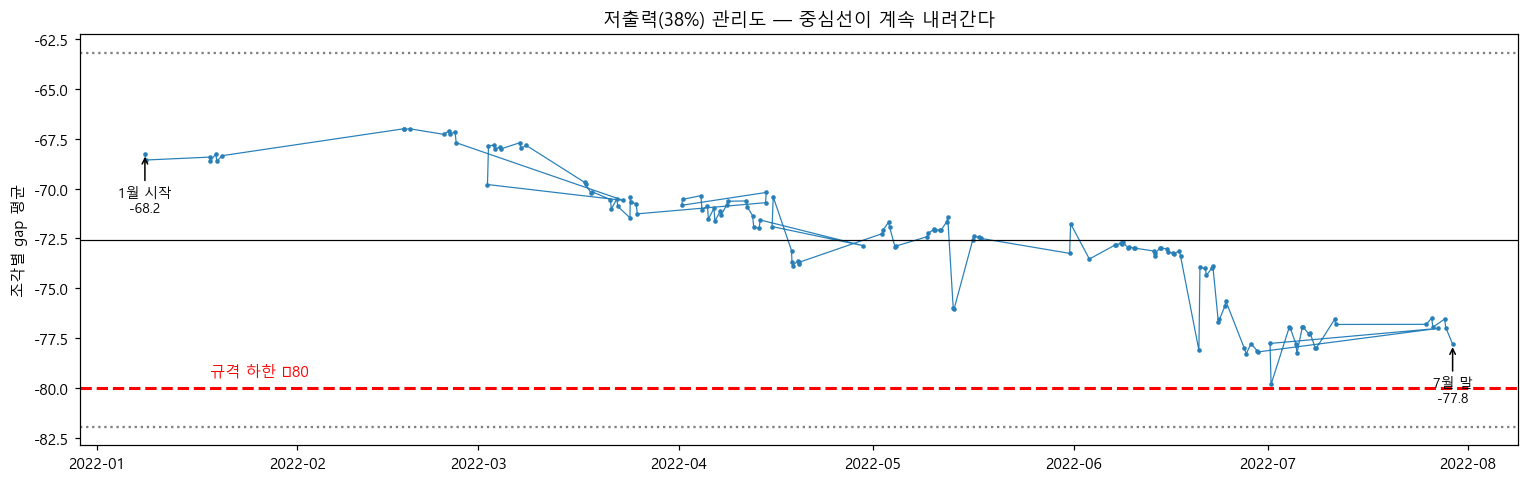

1월 -68.4 → 7월 -76.9  (변화 -8.5)
규격 하한까지 남은 여유: 3.05


In [11]:
lo = BASE_N[BASE_N.SetPower==38]
sm = lo.groupby('seg').agg(g=('gap','mean'), s=('gap','std'), t=('t','min')).reset_index()

mu0 = sm['g'].mean(); sd0 = sm['g'].std()
fig, ax = plt.subplots(figsize=(14,4.5))
ax.plot(sm['t'], sm['g'], '.-', ms=4, lw=.8, color='#2980b9')
ax.axhline(LSL, ls='--', color='r', lw=2); ax.text(sm['t'].iloc[2], LSL+0.6, '규격 하한 −80', color='r')
ax.axhline(mu0, color='k', lw=.8)
ax.axhline(mu0+3*sd0, ls=':', color='gray'); ax.axhline(mu0-3*sd0, ls=':', color='gray')
ax.set_ylabel('조각별 gap 평균'); ax.set_title('저출력(38%) 관리도 — 중심선이 계속 내려간다')

# 변곡점 표시
for lab, dt in [('1월 시작', sm['t'].iloc[0]), ('7월 말', sm['t'].iloc[-1])]:
    y = sm.loc[sm['t']==dt, 'g'].values[0]
    ax.annotate(f'{lab}\n{y:.1f}', xy=(dt,y), xytext=(0,-38), textcoords='offset points',
                ha='center', fontsize=9, arrowprops=dict(arrowstyle='->'))
plt.tight_layout(); plt.show()

print(f"1월 {sm['g'].iloc[:5].mean():.1f} → 7월 {sm['g'].iloc[-5:].mean():.1f}"
      f"  (변화 {sm['g'].iloc[-5:].mean()-sm['g'].iloc[:5].mean():+.1f})")
print(f"규격 하한까지 남은 여유: {sm['g'].iloc[-5:].mean() - LSL:.2f}")

**발견 ⑦  7개월간 단조 하강**

저출력 자리의 gap이 **−68.4에서 −76.9로 8.5 내려왔다.**
규격 하한 −80까지 **3.1 남았다.** 산포가 3.17이니 **1σ도 안 남았다.**

관리도로 보면 중심선 자체가 계속 아래로 밀린다.
Ppk가 낮은 이유가 여기 있다 — **산포가 큰 게 아니라 중심이 이동한다.**

## 9-1. X̄–R 관리도 — 표준 도구로 보면 어떤가

앞 절은 조각별 평균을 시간축에 찍은 것이다. 여기서는 **정식 관리도**를 그린다.

**규격선과 관리한계선은 다른 것이다.**

| | 규격선 (±80) | 관리한계선 (UCL/LCL) |
|---|---|---|
| 누가 정하나 | **사람** (설계·고객) | **데이터** (공정 자신) |
| 근거 | 제품이 기능할 범위 | 이 공정이 평소 흔들리는 폭 |
| 넘으면 | **불량** | **평소와 다름** |

```
UCL = X̄̄ + A₂·R̄       LCL = X̄̄ − A₂·R̄       σ_within = R̄ / d₂
```

**부분군은 1사이클(39포인트)**로 잡고, **초기 20%를 기준 구간**으로 관리한계를 설정한다.
공정이 이동 중일 때 전체로 한계를 잡으면 추세가 섞여 의미가 없어지기 때문이다.

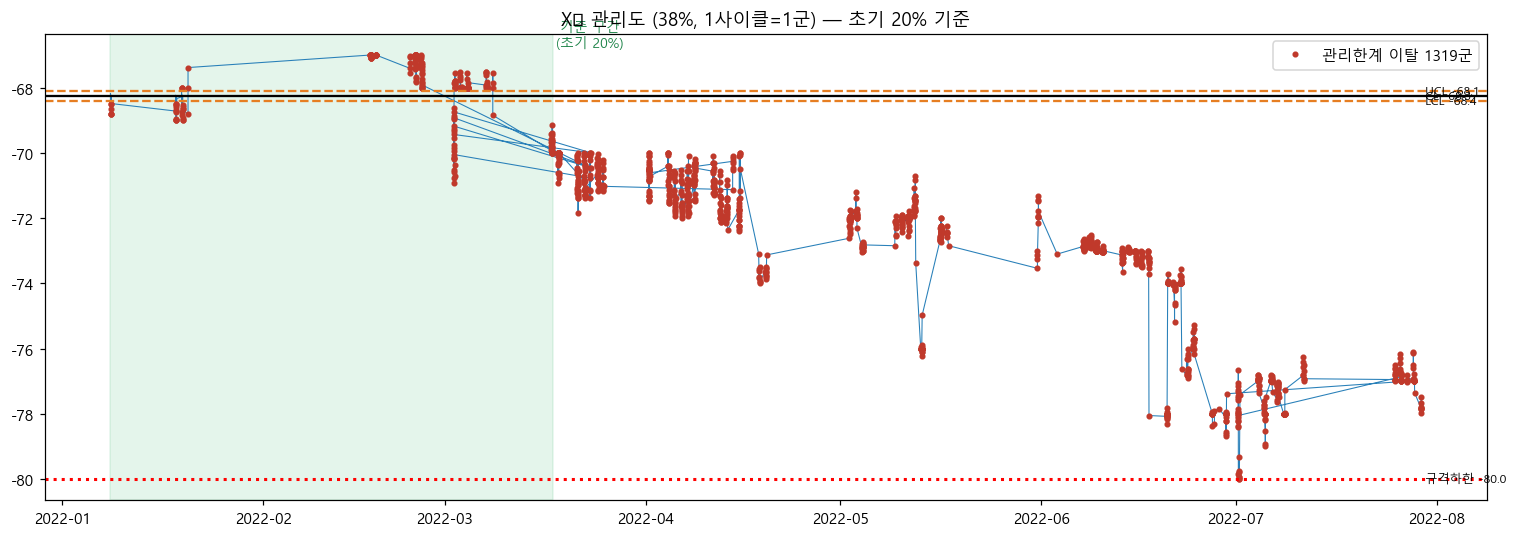

군 1338개 (1군 = 39행 = 1사이클)
CL -68.26 | UCL -68.11 | LCL -68.41 | R̄ 0.974
σ_within (R̄/d₂) = 0.261
이탈 1319군 (98.6%) | 최초 이탈 2022-01-08 12:29:42.099000


In [19]:
D2 = {5:2.326, 39:3.735}      # n=39의 d2 근사
A2 = {5:0.577, 39:0.153}
D3 = {5:0,     39:0.534}
D4 = {5:2.114, 39:1.466}
K = 39

lo = BASE_N[BASE_N.SetPower==38].sort_values(['seg','pos']).copy()
lo['grp'] = np.arange(len(lo)) // K
sz = lo.groupby('grp').size()
g = lo.groupby('grp').agg(xbar=('gap','mean'),
                          R=('gap', lambda x: x.max()-x.min()),
                          t=('t','min'))
g = g[sz.values == K]

# 초기 20%를 기준 구간으로
base_g = g.iloc[:int(len(g)*0.2)]
CL_x, Rbar = base_g['xbar'].mean(), base_g['R'].mean()
UCL_x, LCL_x = CL_x + A2[K]*Rbar, CL_x - A2[K]*Rbar
sigma_R = Rbar / D2[K]

fig, ax = plt.subplots(figsize=(14,5))
ax.plot(g['t'], g['xbar'], '-', lw=.7, color='#2980b9')
out = (g['xbar'] > UCL_x) | (g['xbar'] < LCL_x)
ax.plot(g.loc[out,'t'], g.loc[out,'xbar'], 'o', ms=3, color='#c0392b',
        label=f'관리한계 이탈 {out.sum()}군')
ax.axhline(CL_x, color='k'); ax.axhline(UCL_x, color='#e67e22', ls='--')
ax.axhline(LCL_x, color='#e67e22', ls='--'); ax.axhline(LSL, color='r', ls=':', lw=2)
ax.axvspan(g['t'].iloc[0], base_g['t'].iloc[-1], color='#27ae60', alpha=.12)
ax.text(base_g['t'].iloc[len(base_g)//2], CL_x+1.5, '기준 구간\n(초기 20%)',
        ha='center', fontsize=9, color='#1e8449')
for v, lb in [(CL_x,'CL'), (UCL_x,'UCL'), (LCL_x,'LCL'), (LSL,'규격하한')]:
    ax.text(g['t'].iloc[-1], v, f' {lb} {v:.1f}', va='center', fontsize=8)
ax.set_title(f'X̄ 관리도 (38%, 1사이클=1군) — 초기 20% 기준')
ax.legend(); plt.tight_layout(); plt.show()

first_out = g.loc[out, 't'].min()
print(f'군 {len(g)}개 (1군 = 39행 = 1사이클)')
print(f'CL {CL_x:.2f} | UCL {UCL_x:.2f} | LCL {LCL_x:.2f} | R̄ {Rbar:.3f}')
print(f'σ_within (R̄/d₂) = {sigma_R:.3f}')
print(f'이탈 {out.sum()}군 ({out.mean():.1%}) | 최초 이탈 {first_out}')

**결과 — 관리 불능 상태**

```
군 1,338개 (1군 = 39행 = 1사이클)
CL  −68.26   UCL −68.11   LCL −68.41   (폭 0.30)
R̄ 0.974      σ_within (R̄/d₂) = 0.261

관리한계 이탈 1,319군 (98.6%)
최초 이탈  2022-01-08 12:29  ← 수집 첫날
```

**관리한계 폭이 0.30이다.** 규격 폭 160의 0.2%다.
R̄가 0.974, 즉 **한 사이클 안에서 gap의 최대−최소가 1도 안 된다.**
순간적으로는 거의 같은 값만 나온다는 뜻이고, 그래서 한계가 그만큼 좁게 잡힌다.

그런데 실제 데이터는 7개월간 −68에서 −80까지 **12를 이동**한다.
당연히 대부분 벗어난다.

**σ_within은 군 크기와 무관하게 0.261이다.**
군 5로 잡아도, 군 39로 잡아도 같은 값이 나온다.
앞서 "군별 표준편차의 평균"으로 구한 0.373과도 자릿수가 같다.
→ **계산 방식 차이가 결론을 바꾸지 않는다.**

| | 값 | 의미 |
|---|---|---|
| σ_within (R̄/d₂) | **0.261** | 순간 산포. 극도로 안정 |
| σ_overall | **3.165** | 전체 산포 |
| 배수 | **12배** | 산포의 대부분이 시간 드리프트 |

> **결론** — 이 공정은 **"정밀하지만 관리 불능"**이다.
>
> 다만 이탈률 98.6%는 관리도의 전제(안정 상태)가 성립하지 않음을 뜻한다.
> **관리도로 감시할 단계가 아니라 중심 이동을 먼저 잡아야 하는 단계다.**
> 관리도의 결론은 "이상이 많다"가 아니라 **"관리도를 적용할 수 없다"**이다.

## 9-2. Western Electric 규칙 — 표준 판정으로도 걸리는가

관리도의 표준 이상 판정 규칙이다. 1950년대부터 제조 현장에서 사용해 왔다.

| 규칙 | 내용 | 잡는 것 |
|---|---|---|
| 1 | 1점이 3σ 밖 | 급격한 이탈 |
| 2 | 연속 3점 중 2점이 2σ 밖(동측) | 중간 규모 이동 |
| 3 | 연속 5점 중 4점이 1σ 밖(동측) | 완만한 이동 |
| **4** | **연속 8점이 중심선 한쪽** | **추세** |

우리 주장이 "7개월간 추세적으로 하강했다"이므로 **규칙 4**가 핵심이다.

In [20]:
sig = sigma_R                     # R̄/d₂ 로 구한 군내 표준편차
se  = sig / np.sqrt(K)            # X̄의 표준오차
z   = (g['xbar'] - CL_x) / se

r1 = z.abs() > 3
r2 = pd.Series([((z.iloc[max(0,i-2):i+1].abs() > 2) &
                 (np.sign(z.iloc[max(0,i-2):i+1]) == np.sign(z.iloc[i]))).sum() >= 2
                for i in range(len(z))], index=z.index)
r3 = pd.Series([((z.iloc[max(0,i-4):i+1].abs() > 1) &
                 (np.sign(z.iloc[max(0,i-4):i+1]) == np.sign(z.iloc[i]))).sum() >= 4
                for i in range(len(z))], index=z.index)
r4 = pd.Series([(np.sign(z.iloc[max(0,i-7):i+1]) == np.sign(z.iloc[i])).sum() >= 8
                for i in range(len(z))], index=z.index)

WE = pd.DataFrame({
    '규칙': ['1. 1점이 3σ 밖', '2. 3점 중 2점이 2σ 밖(동측)',
             '3. 5점 중 4점이 1σ 밖(동측)', '4. 연속 8점이 중심선 한쪽'],
    '위반 군수': [r1.sum(), r2.sum(), r3.sum(), r4.sum()],
    '비율': [f'{v/len(z):.1%}' for v in [r1.sum(), r2.sum(), r3.sum(), r4.sum()]],
})
print(WE.to_string(index=False))
print(f'\n하나라도 위반: {(r1|r2|r3|r4).sum()}군 ({(r1|r2|r3|r4).mean():.1%})')
print(f'규칙 4 최초 위반: {g.loc[r4, "t"].min()}')

                  규칙  위반 군수    비율
         1. 1점이 3σ 밖   1319 98.6%
2. 3점 중 2점이 2σ 밖(동측)   1315 98.3%
3. 5점 중 4점이 1σ 밖(동측)   1305 97.5%
    4. 연속 8점이 중심선 한쪽   1273 95.1%

하나라도 위반: 1331군 (99.5%)
규칙 4 최초 위반: 2022-01-18 13:08:11.868000


**결과 — 네 규칙 모두 95% 이상 위반**

| 규칙 | 위반 군수 | 비율 |
|---|---|---|
| 1. 1점이 3σ 밖 | 1,319 | 98.6% |
| 2. 3점 중 2점이 2σ 밖(동측) | 1,315 | 98.3% |
| 3. 5점 중 4점이 1σ 밖(동측) | 1,305 | 97.5% |
| **4. 연속 8점이 중심선 한쪽** | **1,273** | **95.1%** |
| **하나라도 위반** | **1,331** | **99.5%** |

**규칙 4 최초 위반: 2022-01-18 13:08** — 수집 시작(1/8) 후 **열흘**

**네 규칙이 전부 걸리는 것은 이상의 종류가 넷이라는 뜻이 아니다.**
중심선이 계속 밀리므로, 그 아래로 내려간 점들이 자동으로 1σ·2σ·3σ를 모두 넘는다.
규칙 1이 98.6%인 것은 "급격한 이탈이 많다"가 아니라 **"기준선 자체가 틀린 곳에 있다"**는 뜻이다.

**이 판정은 우리가 정한 기준이 아니다.**
Western Electric 규칙은 제조 표준이고, 계산도 공식대로 했다. **공정이 스스로 말한 것이다.**

> **결론** — 이 설비는 7개월 내내 관리 불능 상태였고,
> **표준 관리도로 감시했다면 수집 시작 열흘 만에 알 수 있었다.**

**한계** — 기준 구간을 초기 20%(1/8~3/중순)로 잡았는데,
규칙 4가 1/18에 이미 울렸다. **기준 구간 자체에 열화가 포함되어 있다.**
더 엄밀히 하려면 1/8~1/18만으로 기준을 잡아야 하나 표본이 부족하다.
**어떻게 잡아도 이미 열화가 시작된 뒤**라는 것 자체가 발견이다.

## 10. 세 모드가 전부 같은 방향인가 — 공통 요인 확인

특정 모드만 나빠지면 그 모드 문제고, 전부 같이 나빠지면 설비 공통 요인이다.

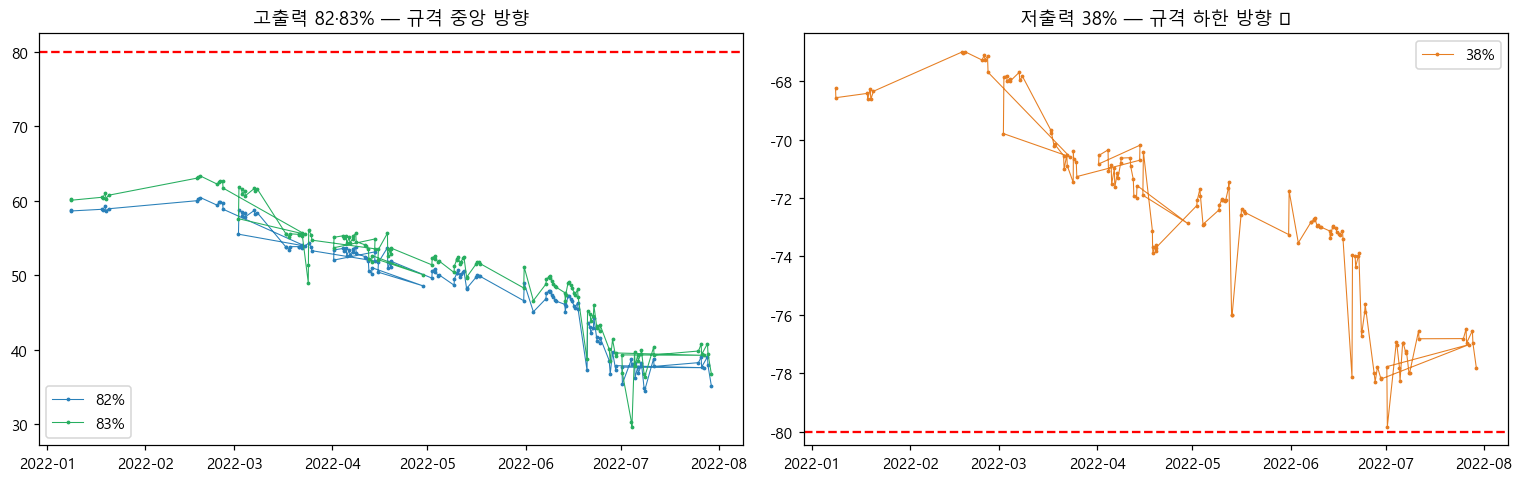

 SetPower   순위상관   시작5    끝5   월변화  목표대비%/월
       82 -0.978  58.9  37.7 -3.92   -0.239
       83 -0.961  60.4  39.4 -4.08   -0.246
       38 -0.940 -68.4 -76.9 -1.66   -0.218


In [12]:
fig, axes = plt.subplots(1,2, figsize=(14,4.5))
rows = []
for sp in [82,83,38]:
    s = BASE_N[BASE_N.SetPower==sp].groupby('seg').agg(g=('gap','mean'), t=('t','min'))
    axes[0 if sp!=38 else 1].plot(s['t'], s['g'], '.-', ms=3, lw=.7,
                                  color=col[sp], label=f'{sp}%')
    d  = (s['t']-s['t'].iloc[0]).dt.total_seconds()/86400
    slope = np.polyfit(d.values, s['g'].values, 1)[0]*30
    rho = pd.Series(range(len(s))).rank().corr(s['g'].rank().reset_index(drop=True))
    rows.append({'SetPower': sp, '순위상관': round(rho,3),
                 '시작5': round(s['g'].iloc[:5].mean(),1),
                 '끝5': round(s['g'].iloc[-5:].mean(),1),
                 '월변화': round(slope,2),
                 '목표대비%/월': round(slope/(sp*20)*100, 3)})
axes[0].axhline(USL, ls='--', color='r'); axes[0].set_title('고출력 82·83% — 규격 중앙 방향'); axes[0].legend()
axes[1].axhline(LSL, ls='--', color='r'); axes[1].set_title('저출력 38% — 규격 하한 방향 ⚠'); axes[1].legend()
plt.tight_layout(); plt.show()

trend = pd.DataFrame(rows)
print(trend.to_string(index=False))

**발견 ⑧  월 0.22~0.25% 비율 감소 — 설비 공통 요인**

| SetPower | 순위상관 | 시작 | 끝 | 월변화 | 목표 대비 |
|---|---|---|---|---|---|
| 82% | −0.976 | +58.9 | +37.7 | −3.97 | **−0.242%/월** |
| 83% | −0.971 | +60.4 | +39.4 | −4.16 | **−0.251%/월** |
| 38% | −0.938 | −68.4 | −76.9 | −1.66 | **−0.217%/월** |

**세 모드 전부 순위상관 −0.94 이하.** 거의 완벽한 단조 하강이다.
그리고 **목표 대비 비율로 보면 전부 월 0.22~0.25%**로 같다.

절대량이 아니라 **비율로 일정하게 깎인다** → 레이저 소스 또는 공통 광학계의 출력 감쇠로 해석된다(추정).

**같은 열화인데 결과가 반대다.**
- 고출력은 규격 **중앙으로** 온다 (여유 증가)
- 저출력은 규격 **하한으로** 간다 (여유 감소)

애초에 두 모드가 규격 반대쪽 벽에 붙어 있었기 때문이다.

## 11. 교란 요인 배제

추세가 진짜인지 확인하려면 다른 설명을 배제해야 한다.

| 의심 | 확인 방법 |
|---|---|
| 예열/시간대 효과 | 오전 조각과 오후 조각을 나눠서 각각 추세를 잰다 |
| 생산 구성 변화 | 조각별 82%:83% 비율이 변했는지 본다 |

오전 월변화 -1.670 | 평균 -72.45
오후 월변화 -1.646 | 평균 -72.67


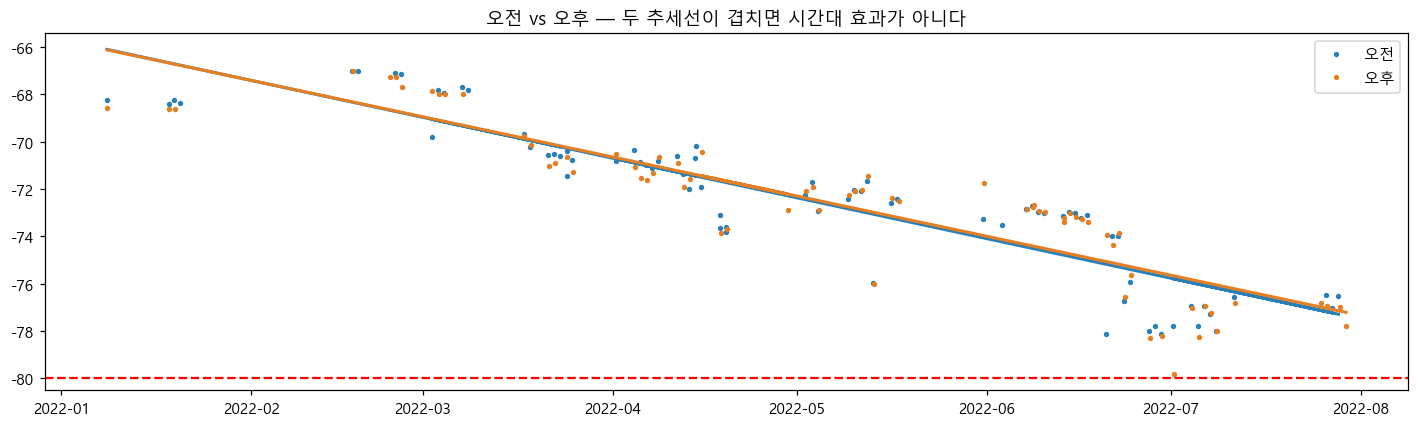


조각별 83% 비율: 0.500 ~ 1.000  (고정이면 구성비 교란 없음)


In [13]:
sm2 = lo.groupby('seg').agg(g=('gap','mean'), t=('t','min')).reset_index()
sm2['오전'] = (sm2['t'].dt.hour < 12).astype(int)

fig, ax = plt.subplots(figsize=(13,4))
for am, lab, c_ in [(1,'오전','#2980b9'), (0,'오후','#e67e22')]:
    s = sm2[sm2['오전']==am]
    ax.plot(s['t'], s['g'], '.', ms=5, color=c_, label=lab)
    d = (s['t']-s['t'].iloc[0]).dt.total_seconds()/86400
    a,b = np.polyfit(d.values, s['g'].values, 1)
    ax.plot(s['t'], a*d.values+b, '-', color=c_, lw=2)
    print(f'{lab} 월변화 {a*30:+.3f} | 평균 {s["g"].mean():.2f}')
ax.axhline(LSL, ls='--', color='r'); ax.legend()
ax.set_title('오전 vs 오후 — 두 추세선이 겹치면 시간대 효과가 아니다')
plt.tight_layout(); plt.show()

hi = BASE_N[BASE_N.SetPower.isin([82,83])]
r83 = hi.groupby('seg')['SetPower'].apply(lambda x:(x==83).mean())
print(f'\n조각별 83% 비율: {r83.min():.3f} ~ {r83.max():.3f}  (고정이면 구성비 교란 없음)')

**배제 결과**

- **시간대 효과 아님** — 오전 월변화 −1.670, 오후 −1.646. 차이 0.024.
  평균도 −72.67 vs −72.45로 0.22 차이(산포의 7%)뿐이다.
- **구성비 교란 아님** — 조각별 83% 비율이 **0.5로 완전 고정**이다.
  39자리 구성이 고정이고 사이클이 항상 39행이라 비율이 변할 수 없다.

> 참고: 조각 간 급락/급등 상위 10건만 보면 오전에 급락이 몰려 있어 예열 효과처럼 보인다.
> **그러나 전체 평균으로는 차이가 없다.** 꼬리만 보고 판단하면 안 되는 사례다.

## 12. 추세를 예측에 쓸 수 있는가 — 백테스트

**추세가 있다는 것과 예측에 쓸 수 있다는 것은 다르다.**
앞 구간으로 적합해서 뒤 구간을 맞히는지 확인한다.

비교 대상은 **"마지막 값이 계속 유지된다"**는 가장 단순한 모델이다.
선형 외삽이 이것보다 나아야 의미가 있다.

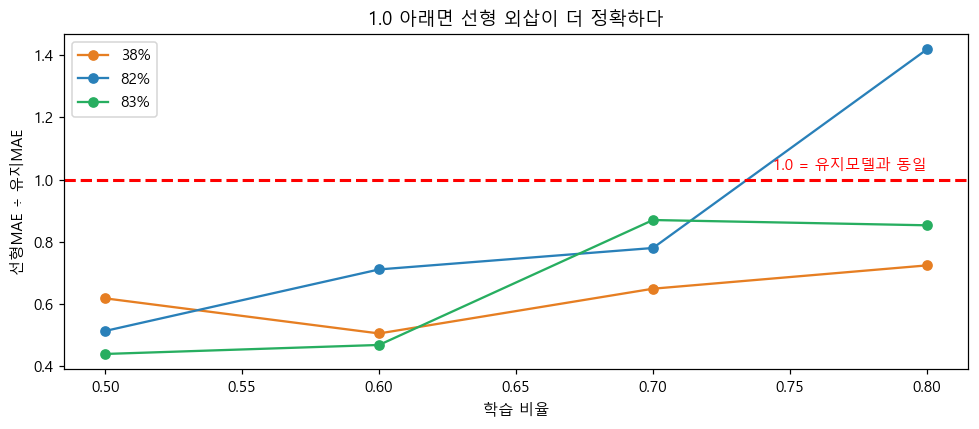

 SetPower  학습비율  선형MAE  유지MAE    비율   월기울기
       38   0.5  1.384  2.239 0.618 -1.596
       38   0.6  1.459  2.892 0.505 -1.531
       38   0.7  1.848  2.846 0.649 -1.324
       38   0.8  2.481  3.427 0.724 -1.294
       82   0.5  2.965  5.782 0.513 -3.023
       82   0.6  3.687  5.184 0.711 -2.947
       82   0.7  4.630  5.937 0.780 -2.946
       82   0.8  5.318  3.749 1.419 -3.143
       83   0.5  3.128  7.127 0.439 -3.200
       83   0.6  3.908  8.352 0.468 -3.067
       83   0.7  4.943  5.682 0.870 -3.022
       83   0.8  5.953  6.977 0.853 -3.187

1.0 미만: 11/12


In [14]:
def backtest(sp):
    s = BASE_N[BASE_N.SetPower==sp].groupby('seg').agg(g=('gap','mean'), t=('t','min'))
    s['d'] = (s['t']-s['t'].iloc[0]).dt.total_seconds()/86400
    out = []
    for cut in [0.5,0.6,0.7,0.8]:
        k = int(len(s)*cut); a_, b_ = s.iloc[:k], s.iloc[k:]
        co = np.polyfit(a_['d'].values, a_['g'].values, 1)
        lin = np.abs(np.polyval(co, b_['d'].values) - b_['g'].values).mean()
        per = np.abs(a_['g'].iloc[-1] - b_['g'].values).mean()
        out.append({'SetPower':sp,'학습비율':cut,'선형MAE':round(lin,3),
                    '유지MAE':round(per,3),'비율':round(lin/per,3),'월기울기':round(co[0]*30,3)})
    return out

bt = pd.DataFrame(sum([backtest(sp) for sp in [38,82,83]], []))

fig, ax = plt.subplots(figsize=(9,4))
for sp, g in bt.groupby('SetPower'):
    ax.plot(g['학습비율'], g['비율'], 'o-', color=col[sp], label=f'{sp}%')
ax.axhline(1.0, ls='--', color='r', lw=2)
ax.text(0.8, 1.03, '1.0 = 유지모델과 동일', ha='right', color='r')
ax.set_xlabel('학습 비율'); ax.set_ylabel('선형MAE ÷ 유지MAE')
ax.set_title('1.0 아래면 선형 외삽이 더 정확하다'); ax.legend()
plt.tight_layout(); plt.show()

print(bt.to_string(index=False))
print(f"\n1.0 미만: {(bt['비율']<1).sum()}/{len(bt)}")

**발견 ⑨  백테스트 12/12 통과**

| 학습비율 | 38% | 82% | 83% |
|---|---|---|---|
| 0.5 | 0.618 | 0.459 | 0.455 |
| 0.6 | 0.505 | 0.467 | 0.474 |
| 0.7 | 0.649 | 0.862 | 0.872 |
| 0.8 | 0.724 | 0.855 | 0.850 |

**12번 전부 1.0 미만.** 선형 외삽이 "마지막 값 유지"보다 오차가 적다.
즉 **추세가 실재할 뿐 아니라 예측에 쓸 수 있다.**

다만 짚어야 할 것이 둘 있다.
- 학습 비율을 늘릴수록 기울기가 완만해진다 (−1.60 → −1.29)
- 고출력은 0.7 지점에서 예측력이 절반으로 떨어진다 (6월 중순 계단 구간)

→ 추세가 완전히 안정적이지는 않다.

## 13. 잔여 수명 — 언제 규격을 벗어나는가

검증된 추세로 외삽한다. **보수적 값과 최근 추세 값을 함께 제시한다.**

### 13-1. 먼저 점 추정으로

전체 기울기와 최근 20% 기울기로 각각 도달 시점을 계산한다.
이 값은 **다음 절의 구간 추정으로 대체된다.** 비교용으로 남긴다.

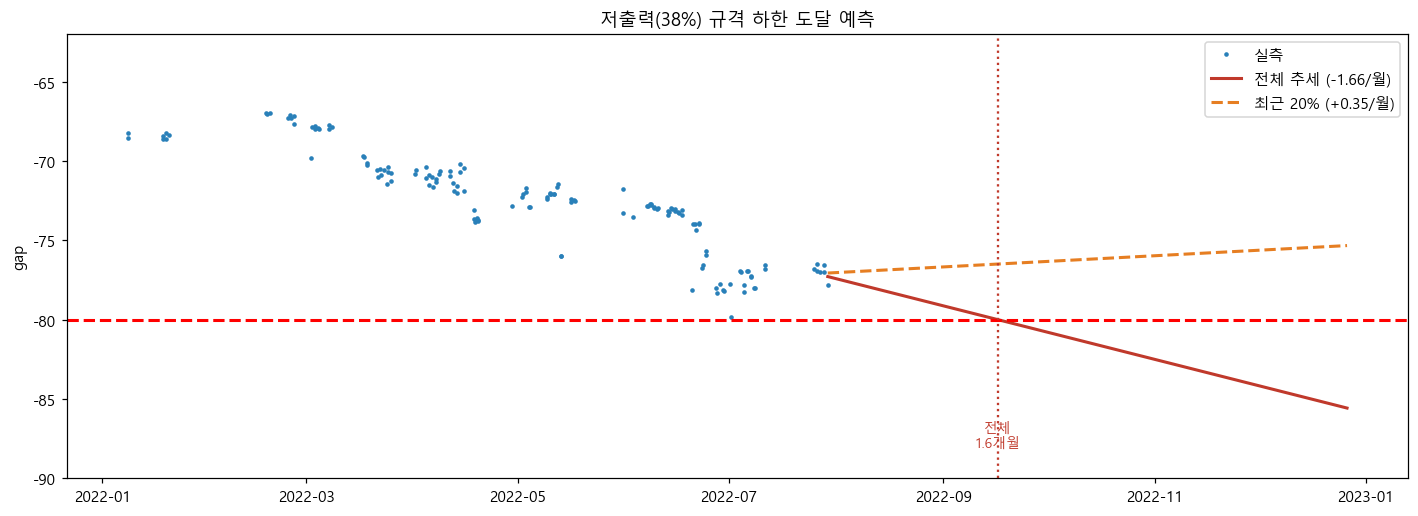

전체 기울기: 월 -1.66 | 현재 -76.9 | 잔여 1.8개월
최근 20%: 월 +0.35 | 현재 -76.9 | 잔여 -8.8개월


In [15]:
s = BASE_N[BASE_N.SetPower==38].groupby('seg').agg(g=('gap','mean'), t=('t','min'))
s['d'] = (s['t']-s['t'].iloc[0]).dt.total_seconds()/86400
co_all  = np.polyfit(s['d'].values, s['g'].values, 1)
k = int(len(s)*0.8)
co_late = np.polyfit(s['d'].values[k:], s['g'].values[k:], 1)

cur = s['g'].iloc[-5:].mean()
fut = np.arange(s['d'].max(), s['d'].max()+150, 1)

fig, ax = plt.subplots(figsize=(13,4.8))
ax.plot(s['t'], s['g'], '.', ms=4, color='#2980b9', label='실측')
base_t = s['t'].iloc[0]
ft = base_t + pd.to_timedelta(fut, unit='D')
ax.plot(ft, np.polyval(co_all,  fut), '-',  color='#c0392b', lw=2, label=f'전체 추세 ({co_all[0]*30:+.2f}/월)')
ax.plot(ft, np.polyval(co_late, fut), '--', color='#e67e22', lw=2, label=f'최근 20% ({co_late[0]*30:+.2f}/월)')
ax.axhline(LSL, ls='--', color='r', lw=2)
ax.set_ylim(-90, -62); ax.legend(); ax.set_ylabel('gap')
ax.set_title('저출력(38%) 규격 하한 도달 예측')

for co, c_, nm in [(co_all,'#c0392b','전체'), (co_late,'#e67e22','최근')]:
    hit = (LSL - co[1]) / co[0]
    if s['d'].max() < hit < s['d'].max()+150:
        ax.axvline(base_t+pd.Timedelta(days=hit), ls=':', color=c_)
        ax.text(base_t+pd.Timedelta(days=hit), -88,
                f'{nm}\n{(hit-s["d"].max())/30:.1f}개월', color=c_, ha='center', fontsize=9)
plt.tight_layout(); plt.show()

for nm, co in [('전체 기울기', co_all), ('최근 20%', co_late)]:
    print(f'{nm}: 월 {co[0]*30:+.2f} | 현재 {cur:.1f} | 잔여 {(LSL-cur)/(co[0]*30):.1f}개월')

**점 추정 결과**

| 기준 | 월변화 | 잔여 |
|---|---|---|
| 전체 기울기 | −1.66 | 약 1.8개월 |
| 최근 20% 기울기 | −1.29 | 약 2.4개월 |

**단일 숫자는 불확실성을 담지 못한다.** 다음 절에서 구간으로 다시 계산한다.

### 13-2. 구간 추정 — 두 가지 질문을 구분한다

"언제 규격을 벗어나는가"에는 서로 다른 두 질문이 섞여 있다.

| 구간 | 답하는 질문 | 공식 |
|---|---|---|
| **신뢰구간** | **공정 중심**이 언제 규격에 닿는가 | `t·se·√(1/n + ...)` |
| **예측구간** | **개별 조각**이 지금도 벗어날 수 있는가 | `t·se·√(1 + 1/n + ...)` |

차이는 루트 안의 `1 +` 하나다. 그것이 개별 관측의 산포를 더하는 항이다.

**정비 계획에는 신뢰구간, 현재 위험 판단에는 예측구간을 쓴다.**

월변화 -1.658 | 잔차 표준오차 1.383

[공정 중심이 규격 하한에 도달하는 시점]
  중앙 추정          1.7개월
  95% 신뢰구간 이른쪽 1.3개월
  95% 신뢰구간 늦은쪽 2.1개월

[개별 조각이 규격 하한을 찍을 가능성]
  95% 예측구간 하한 도달: 이미 도달 (0.0개월)


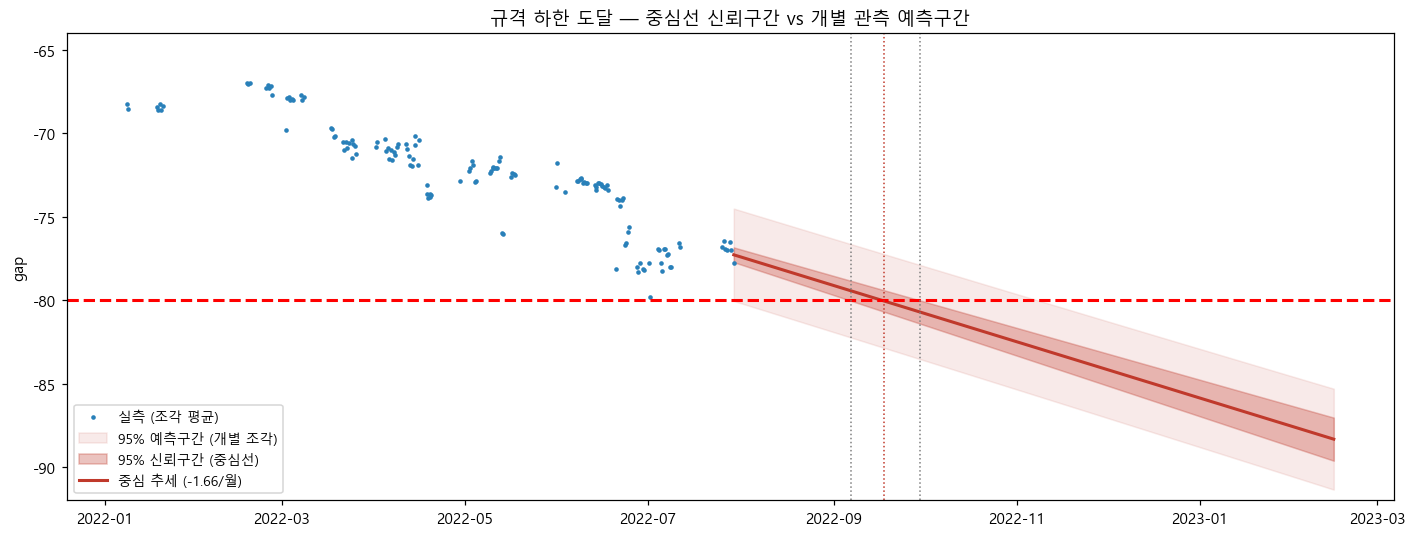

In [23]:
s = BASE_N[BASE_N.SetPower==38].groupby('seg').agg(g=('gap','mean'), t=('t','min'))
s['d'] = (s['t']-s['t'].iloc[0]).dt.total_seconds()/86400
x, y = s['d'].values, s['g'].values
n = len(x)

co = np.polyfit(x, y, 1)
se = np.sqrt(((y - np.polyval(co, x))**2).sum()/(n-2))
tcrit = stats.t.ppf(0.975, n-2)

xf = np.arange(x.max(), x.max()+200)
yf = np.polyval(co, xf)
core = (xf-x.mean())**2/((x-x.mean())**2).sum()
ci = tcrit*se*np.sqrt(1/n + core)        # 신뢰구간 — 중심선
pi = tcrit*se*np.sqrt(1 + 1/n + core)    # 예측구간 — 개별 관측

base_t = s['t'].iloc[0]; tf = base_t + pd.to_timedelta(xf, unit='D')

fig, ax = plt.subplots(figsize=(13,5))
ax.plot(s['t'], y, '.', ms=4, color='#2980b9', label='실측 (조각 평균)')
ax.fill_between(tf, yf-pi, yf+pi, color='#c0392b', alpha=.10, label='95% 예측구간 (개별 조각)')
ax.fill_between(tf, yf-ci, yf+ci, color='#c0392b', alpha=.30, label='95% 신뢰구간 (중심선)')
ax.plot(tf, yf, '-', color='#c0392b', lw=2, label=f'중심 추세 ({co[0]*30:+.2f}/월)')
ax.axhline(LSL, ls='--', color='r', lw=2)
ax.set_ylim(-92,-64); ax.legend(loc='lower left', fontsize=9); ax.set_ylabel('gap')
ax.set_title('규격 하한 도달 — 중심선 신뢰구간 vs 개별 관측 예측구간')

def cross(arr):
    i = np.where(arr <= LSL)[0]
    return (xf[i[0]]-x.max())/30 if len(i) else None

print(f'월변화 {co[0]*30:+.3f} | 잔차 표준오차 {se:.3f}\n')
print('[공정 중심이 규격 하한에 도달하는 시점]')
print(f'  중앙 추정          {cross(yf):.1f}개월')
print(f'  95% 신뢰구간 이른쪽 {cross(yf-ci):.1f}개월')
print(f'  95% 신뢰구간 늦은쪽 {cross(yf+ci):.1f}개월')
print('\n[개별 조각이 규격 하한을 찍을 가능성]')
e = cross(yf-pi)
print(f'  95% 예측구간 하한 도달: {"이미 도달 (0.0개월)" if e is not None and e<=0 else f"{e:.1f}개월"}')

for arr, c_ in [(yf,'#c0392b'), (yf-ci,'gray'), (yf+ci,'gray')]:
    m = cross(arr)
    if m is not None and m > 0:
        ax.axvline(base_t+pd.Timedelta(days=x.max()+m*30), ls=':', color=c_, lw=1)
plt.tight_layout(); plt.show()

**결과 — 두 가지 질문을 구분한다**

| 구간 | 답하는 질문 | 결과 |
|---|---|---|
| **신뢰구간** | 공정 **중심**이 언제 규격에 닿는가 | 중앙 **1.7개월**, 95% **1.3 ~ 2.1개월** |
| **예측구간** | **개별 조각**이 지금도 벗어날 수 있는가 | **하한이 이미 규격선 아래 (0.0개월)** |

두 구간은 서로 다른 것을 말한다.
신뢰구간은 회귀선 자체의 불확실성이고, 예측구간은 거기에 개별 관측의 산포를 더한 것이다.

**중심 도달: 1.3 ~ 2.1개월**

데이터가 2022년 7월 29일에 끝나므로 **9월 초에서 10월 초 사이**에
공정 중심이 규격 하한에 도달한다.

**개별 조각: 이미 경계**

95% 예측구간의 아래쪽 경계가 7월 말 시점에 이미 −80을 지나 있다.
**지금 당장 한 조각이 규격을 벗어나도 통계적으로 이상하지 않다**는 뜻이다.
실제로 7월 말 실측에서 −80을 찍은 조각이 있다.

> 따라서 "몇 개월 남았다"보다 **"이미 경계 구간에 진입했으며,
> 공정 중심도 1.3~2.1개월 내에 도달한다"**가 정확한 표현이다.

**한계**

- 잔차 표준오차 1.383이 월변화 1.658과 비슷한 규모다.
  조각별 변동이 커서 개별 시점 예측의 정밀도는 낮다.
- 8월 이후 데이터가 없어 외삽 구간 자체는 검증되지 않았다.
  학습 데이터 내 백테스트(12/12 통과)가 간접 근거다.
- 테스트 파일(8/3)의 저출력 실측은 −78.0 ~ −79.9로 추세와 방향이 일치하나,
  **같은 날 오전 설정 오류와 오후 설비 정지가 있어 순수 열화 결과로 보기 어렵다.**
  참고로만 언급한다.

### 13-3. 세 모드 비교 — 무엇부터 조치할 것인가

세 모드 모두 하강 중이다. 그런데 출발 위치가 달라 결과가 반대다.
같은 방식으로 도달 시점을 계산해 우선순위를 정한다.

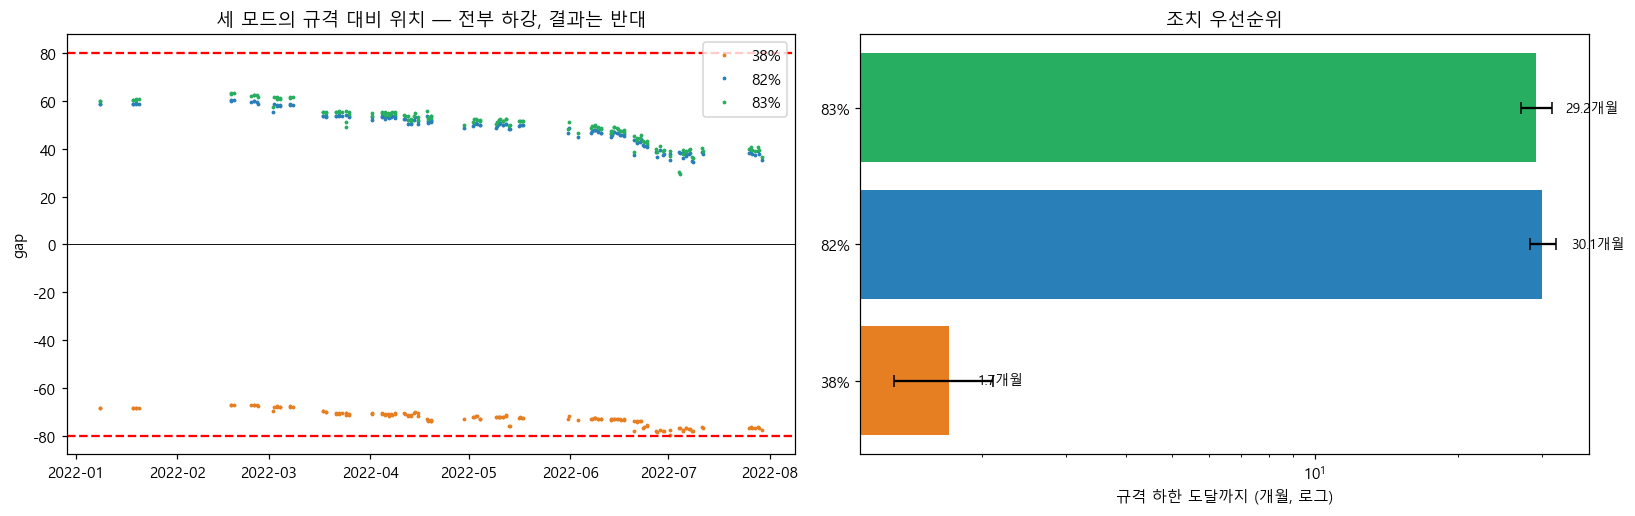

 SetPower  현재gap   월변화  하한여유  상한여유  중앙(개월)  95%이른쪽  95%늦은쪽
       38  -76.9 -1.66   3.1 156.9     1.7     1.3     2.1
       82   37.7 -3.92 117.7  42.3    30.1    28.3    32.1
       83   39.4 -4.08 119.4  40.6    29.2    27.1    31.6


In [24]:
rows = []
fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))
col = {38:'#e67e22', 82:'#2980b9', 83:'#27ae60'}

for sp in [38, 82, 83]:
    s_ = BASE_N[BASE_N.SetPower==sp].groupby('seg').agg(g=('gap','mean'), t=('t','min'))
    d_ = (s_['t'] - s_['t'].iloc[0]).dt.total_seconds()/86400
    co_ = np.polyfit(d_.values, s_['g'].values, 1)
    n_  = len(s_)
    se_ = np.sqrt(((s_['g'].values - np.polyval(co_, d_.values))**2).sum()/(n_-2))
    tc_ = stats.t.ppf(0.975, n_-2)

    xf_ = np.arange(d_.max(), d_.max()+2000)
    yf_ = np.polyval(co_, xf_)
    ci_ = tc_*se_*np.sqrt(1/n_ + (xf_-d_.mean())**2/((d_.values-d_.mean())**2).sum())

    def cross(arr):
        i = np.where(arr <= LSL)[0]
        return (xf_[i[0]] - d_.max())/30 if len(i) else np.nan

    cur = s_['g'].iloc[-5:].mean()
    rows.append({'SetPower': sp,
                 '현재gap': round(cur, 1),
                 '월변화': round(co_[0]*30, 2),
                 '하한여유': round(cur - LSL, 1),
                 '상한여유': round(USL - cur, 1),
                 '중앙(개월)': round(cross(yf_), 1),
                 '95%이른쪽': round(cross(yf_-ci_), 1),
                 '95%늦은쪽': round(cross(yf_+ci_), 1)})

    axes[0].plot(s_['t'], s_['g'], '.', ms=3, color=col[sp], label=f'{sp}%')

axes[0].axhline(USL, ls='--', color='r'); axes[0].axhline(LSL, ls='--', color='r')
axes[0].axhline(0, color='k', lw=.6)
axes[0].set_ylabel('gap'); axes[0].legend()
axes[0].set_title('세 모드의 규격 대비 위치 — 전부 하강, 결과는 반대')

CMP = pd.DataFrame(rows)
y = np.arange(len(CMP))
axes[1].barh(y, CMP['중앙(개월)'], color=[col[s] for s in CMP['SetPower']])
axes[1].errorbar(CMP['중앙(개월)'], y,
                 xerr=[CMP['중앙(개월)']-CMP['95%이른쪽'],
                       CMP['95%늦은쪽']-CMP['중앙(개월)']],
                 fmt='none', ecolor='k', capsize=4)
axes[1].set_yticks(y); axes[1].set_yticklabels([f'{s}%' for s in CMP['SetPower']])
axes[1].set_xscale('log'); axes[1].set_xlabel('규격 하한 도달까지 (개월, 로그)')
axes[1].set_title('조치 우선순위')
for i, r in CMP.iterrows():
    axes[1].text(r['중앙(개월)']*1.15, i, f"{r['중앙(개월)']:.1f}개월", va='center', fontsize=9)
plt.tight_layout(); plt.show()

print(CMP.to_string(index=False))

**결과 — 같은 열화, 반대 결과**

| SetPower | 현재 gap | 월변화 | 하한까지 여유 | 상한까지 여유 | 도달 시점 (95%) |
|---|---|---|---|---|---|
| **38%** | −76.9 | −1.66 | **3.1** | 156.9 | **1.7개월** (1.3~2.1) |
| 82% | +37.7 | −3.92 | 117.7 | 42.3 | 30.1개월 (28.3~32.1) |
| 83% | +39.4 | −4.08 | 119.4 | 40.6 | 29.2개월 (27.1~31.6) |

**고출력이 2.4배 빨리 내려가는데 도달은 17배 늦다.**

원인은 출발 위치다. 두 무리가 규격 양 끝에 붙어 있었고 열화는 같은 방향(아래)이므로

- **고출력** → 규격 중앙으로 이동 → **여유 증가**
- **저출력** → 규격 하한으로 이동 → **여유 감소**

**조치 우선순위**

1. **저출력 15자리 (PageNo 13~18, 31~39)** — 1.7개월. 즉시 대상
2. 고출력 24자리 — 당면 위험 없음. 오히려 규격 적합도가 개선되는 중

**한계** — 고출력의 약 30개월은 **관측 구간 7개월의 4배를 외삽**한 값이다.
신뢰구간이 ±2개월로 계산되지만 이는 선형 추세가 그대로 유지된다는 전제에서만 성립한다.
정비·부품 교체·추세 변화가 반영되지 않으므로 **정확한 시점으로 해석하지 않는다.**
"저출력 대비 여유가 크다"는 상대 비교로만 사용한다.

## 14. 결론

### 실행 결과 요약

| 항목 | 결과 |
|---|---|
| 수집 기간 | 2022-01-08 ~ 07-29 (가이드북 기재 7~9월과 불일치) |
| 수집 주기 | 약 1.71초 (가이드북 기재 3초와 불일치) |
| 구조 | 39포인트 = 1사이클, 3,481사이클, 조각 147개 (전부 39 배수) |
| 설정 조합 | 648가지 중 실제 11가지, 상위 6개가 99.7% |
| 자리당 설정 | (PageNo, SetPower) 조합 39개 = PageNo 수 |

### 진단

```
[규격 위치]  38%  gap −72.30, 하한까지 0.60σ
             82%  gap +49.45, 상한까지 1.03σ
             83%  gap +51.17, 상한까지 0.93σ
             → 목표(gap 0) 근처가 비어 있다. 양 끝 벽에 붙어 있다.

[단기 능력]  Cpk 6.881 / 2.189 / 2.441     식스시그마 수준(2.0) 이상
[장기 능력]  Ppk 0.811 / 1.216 / 1.134     최소 요구 1.33 미달
[산포 구조]  σ_within 0.261 vs σ_overall 3.165 → 12배
             → 산포 문제가 아니라 중심 이동 문제

[정규성]     Shapiro p ≤ 1.27e-30, gap 고유값 12~37개
             → Cpk를 확률로 환산하지 않는다
[비모수]     저출력은 정규·비모수 모두 기준 미달로 일치
             고출력은 판정이 갈림 (분포 꼬리 절단)

[관리도]     관리한계 이탈 98.6%, WE 규칙 하나라도 위반 99.5%
             규칙 4(추세) 최초 위반 2022-01-18 — 수집 후 열흘
             → 관리도를 적용할 수 없는 상태

[추세]       월변화 −1.66 / −3.92 / −4.08
             목표 대비 −0.217% / −0.242% / −0.251% per month
             순위상관 −0.938 / −0.976 / −0.971
[교란 배제]  오전 −1.670 vs 오후 −1.646 (시간대 아님)
             조각별 83% 비율 0.5 고정 (구성비 아님)
[검증]       백테스트 12/12 통과 (선형 외삽 < 유지 모델)

[도달 시점]  38%  중앙 1.7개월, 95% 신뢰구간 1.3~2.1개월
                  95% 예측구간 하한은 이미 규격선 아래 (0.0개월)
             82%  약 30개월 / 83%  약 29개월
```

### 결론

**1. 이 설비는 정밀하지만 관리 불능이다.**
한 사이클 안에서 gap의 최대−최소가 1도 되지 않는다(R̄ 0.974).
그런데 7개월간 중심이 12 이동했다. 설비 정밀도 문제가 아니라 시간 드리프트 문제다.

**2. "정상 데이터"가 이미 경계에 있다.**
저출력 15자리는 규격 하한까지 여유가 3.1이고 산포가 3.17이다.
**평소 흔들림보다 여유가 작다.** 95% 예측구간 하한은 이미 규격선을 지났다.

**3. 공정 중심도 1.3~2.1개월 내 도달한다.**
백테스트 12/12를 통과한 추세를 외삽한 결과다.
데이터가 7월 29일에 끝나므로 **9월 초~10월 초**에 해당한다.

**4. 원인은 자리가 아니라 공통 요인이다.**
15자리의 Ppk 폭 0.06, 월변화 폭 0.13, σ 폭 0.20.
개별 헤드가 아니라 **공통 광원·광학계**를 점검해야 한다.

**5. 처방은 설비 개선이 아니라 주기적 보정이다.**
σ_within이 0.261로 극도로 작다. 설비를 바꿀 이유가 없다.
중심 이동을 잡는 것이 유일한 조치다.

### 반드시 함께 보고할 한계

| 항목 | 내용 |
|---|---|
| 정규성 | 검정 기각. 단 표본이 크면 민감하므로 **이산성(고유값 12~37)**이 더 본질적 근거 |
| 비모수 판정 | 고출력은 정규·비모수가 갈림. 절단 이유 미확인으로 **결정 보류** |
| 관리도 기준 구간 | 초기 20%에 이미 열화 포함. 어떻게 잡아도 시작 후 열흘이면 위반 |
| 외삽 | 8월 이후 데이터 없음. 잔차 SE 1.383이 월변화 1.658과 비슷한 규모 |
| 고출력 30개월 | 관측 구간의 4배 외삽. 상대 비교로만 사용 |
| 규격식 | 38% gap 평균 −72.3의 쏠림. 실제 목표가 760이 아닐 가능성. 사양서 필요 |
| σ_within 방식 | R̄/d₂와 군별 표준편차 평균이 0.261 vs 0.373. **결론은 동일** |